## Composite of submesoscale cyclonic eddy

In [1]:
from smode_import import *
from parula import parula

In [2]:
# drifters data
SMODE_DATA_folder = '/Users/elise/data/SMODE-data/'
dr_files = sorted(glob(SMODE_DATA_folder+'drifters/2023/'+'SMODE_IOP2_surface_drifter_0*.nc'))
if not dr_files: print('No files found')

# underway ship data
uw = xr.open_dataset(SMODE_DATA_folder+'TSG/'+'IOP2_underway.nc')
uw

# TSG
TSG = xr.open_dataset('/Users/elise/data/SMODE-data/S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
#TSG['time_bio'] + np.timedelta64(7, 'h') ## IMPORTANT CONVERT TO LOCAL TIME
TSG

<xarray.Dataset> Size: 40MB
Dimensions:                              (time_bio: 32509, time: 147912,
                                          instrument: 1)
Coordinates:
  * time_bio                             (time_bio) datetime64[ns] 260kB 2023...
    latitude_bio                         (time_bio) float64 260kB ...
    longitude_bio                        (time_bio) float64 260kB ...
  * time                                 (time) datetime64[ns] 1MB 2023-04-07...
    latitude                             (time) float64 1MB ...
    longitude                            (time) float64 1MB ...
Dimensions without coordinates: instrument
Data variables: (12/47)
    TSG86                                (instrument) float64 8B ...
    TSG73                                (instrument) float64 8B ...
    SST62                                (instrument) float64 8B ...
    FLW19                                (instrument) float64 8B ...
    FLW20                                (instrument) float64 8B ...
    FLW09                                (instrument) float64 8B ...
    ...                                   ...
    beam_attenuation_657nm_ACS           (time_bio) float64 260kB ...
    chlorophyll_flourometer              (time_bio) float64 260kB ...
    particulate_organic_carbon_cstar     (time_bio) float64 260kB ...
    photosynthetically_active_radiation  (time_bio) float64 260kB ...
    CSTAR_QCflag                         (time_bio) float64 260kB ...
    flowrate_time_bio                    (time_bio) float64 260kB 2.844 ... 1...
Attributes: (12/52)
    DOI:                           10.5067/SMODE-RVTSG
    title:                         SMODE Shipboard bio-optical, meteorlogical...
    summary:                       Level-2 processed data from GPS, TSG and F...
    keywords:                      EARTH SCIENCE > OCEANS > OPTICS > ATTENUAT...
    keywords_vocabulary:           NASA Global Change Master Directory (GCMD)...
    conventions:                   CF-1.8, ACDD-1.3
    ...                            ...
    timetime_coverage_end:         2023-05-03T15:05:07Z
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    date_created:                  2023-04-13T00:00:00Z
    time_coverage_duration:        P25D20H10M57S
    comment:                       See readme.txt. Thermosalinograph Data are...

In [3]:
def interp_ship_on_drifter(underway_data, drifter, dist=1):
    from scipy.interpolate import interp1d
    # drifter data
    time_dr= drifter.time
    lat_dr = drifter.latitude
    lon_dr = drifter.longitude

    def is_night(timestamp,delta=-7): #account for photochemical quenching
        # UTC to PST delta=-7
        return (timestamp.dt.hour < 9-delta) | (timestamp.dt.hour >= 17-delta)
    
    def interpolate_function(time_dr,time_uw,variable):
        num_time_uw      = time_uw.astype('int64') / 1e9 # nanoseconds to seconds
        num_time_drifter = time_dr.astype('int64') / 1e9
        interp_function  = interp1d(num_time_uw, variable, kind='linear',fill_value=np.nan, bounds_error=False)
        interpolated_data= interp_function(num_time_drifter)
        return interpolated_data
        
    # Interpolate ship data onto drifter time
    interp_lon = interpolate_function(time_dr,underway_data.time,underway_data.lon)
    interp_lat = interpolate_function(time_dr,underway_data.time,underway_data.lat)
    interp_chl = interpolate_function(time_dr,underway_data.time,underway_data.chl)
    interp_temp = interpolate_function(time_dr,underway_data.time,underway_data.temp)
    interp_salt = interpolate_function(time_dr,underway_data.time,underway_data.salt)
    interp_rho = interpolate_function(time_dr,underway_data.time,underway_data.rho)
    interp_o2sat = interpolate_function(time_dr,underway_data.time,underway_data.o2sat)
    
    # Save chlorophyll values when dist < 1 km  & nighttime
    distances = haversine(lat_dr, lon_dr, interp_lat, interp_lon) # pairwise distances
    if nighttime==1: idx = (distances <= dist) & (is_night(time_dr))
    else: idx = (distances <= dist)
    
    # logarithmic chlorophyll rate of change
    dChldt_ship = np.empty(len(time_dr[idx]))*np.nan
    #dChl = np.diff(interp_chl[idx]) # mg m-3
    dChl = np.log(interp_chl[idx][1:] / interp_chl[idx][:-1])
    dt   = (time_dr[idx].diff(dim='time')*1e-9).astype(float) # seconds
    dt   = dt/86400. # convert to day
    dChldt_ship[1::] = dChl/dt

    # dSSSdt
    dSSSdt_ship = np.empty(len(time_dr[idx]))*np.nan
    dSSS = np.diff(interp_salt[idx]) # mg m-3
    dSSSdt_ship[1::] = dSSS/dt
    
    dataset = xr.Dataset(
    {
        'lon': ('time', lon_dr[idx].values),
        'lat': ('time', lat_dr[idx].values),
        'chl': ('time', interp_chl[idx]),
        'temp': ('time', interp_temp[idx]),
        'salt': ('time', interp_salt[idx]),
        'rho': ('time', interp_rho[idx]),
        'o2sat': ('time', interp_o2sat[idx]),
        'dChldt': ('time', dChldt_ship),
        'dSSSdt': ('time', dSSSdt_ship),
    },
    coords={'time': time_dr[idx].values},
    attrs={'name': drifter.title[-7::]},
    )
    
    return dataset
    

In [4]:
#TSG.photosynthetically_active_radiation.plot()
#plt.xlim(pd.Timestamp('2023-04-19'),pd.Timestamp('2023-04-20'))

In [5]:
def interp_ship_on_drifter_ACS(TSG, drifter, resample, dist=1):
        
    # chlorohypll flowrate control
    flowrate_okay = np.where(TSG.flowrate_time_bio>1.)

    # Resample data
    TSG_longitude   = TSG.longitude_bio.resample(time_bio=resample).mean()
    TSG_latitude    = TSG.latitude_bio.resample(time_bio=resample).mean()
    TSG_chlorophyll = TSG.chlorophyll_ACS[flowrate_okay].resample(time_bio=resample).mean()
    
    # Interpolate ship data onto drifter time
    interp_lon = TSG_longitude.interp(time_bio=drifter.time, method='linear')
    interp_lat = TSG_latitude.interp(time_bio=drifter.time, method='linear')
    interp_chl = TSG_chlorophyll.interp(time_bio=drifter.time, method='linear')
    
    # Save chlorophyll values when dist < 1 km
    distances = haversine(drifter.latitude, drifter.longitude, interp_lat, interp_lon) # pairwise distances
    idx = (distances <= dist)
    
    # Logarithmic chlorophyll rate of change
    # dP/dt = P2 * log(P2/P1) / dt
    dChldt_ship = np.empty(len(drifter.time[idx]))*np.nan
    P1,P2 = interp_chl[idx][:-1].values, interp_chl[idx][1:].values
    dChl = np.log(P2/P1)
    dt   = (drifter.time[idx].diff(dim='time')*1e-9).astype(float) # seconds
    #print(dChldt_ship.shape,dChl.shape,dt.shape)
    dt   = dt/86400. # convert to day
    dChldt_ship[1::] = dChl/dt
    
    dataset = xr.Dataset(
    {
        'lon': ('time', drifter.longitude[idx].values),
        'lat': ('time', drifter.latitude[idx].values),
        'chl': ('time', interp_chl[idx].values),
        'dChldt': ('time', dChldt_ship),
        'dist_from_ship': ('time', distances[idx].values),
    },
    coords={'time': drifter.time[idx].values},
    attrs={'name': drifter.title[-7::]},
    )
    
    return dataset
    

In [6]:
IDs=['4696942', '4697436', '4697439', '4697491', '4697532', '4697629', '4697637', '4704406'] # favorites

#for ID in IDs[0:1]:
#    drifter = xr.open_dataset(SMODE_DATA_folder + f'drifters/2023/SMODE_IOP2_surface_drifter_0-{ID}.nc')
#    drifter = drifter.isel(time=drifter.position_QCflag==1)
#    
#    dr = interp_ship_on_drifter(uw, drifter, dist=1)

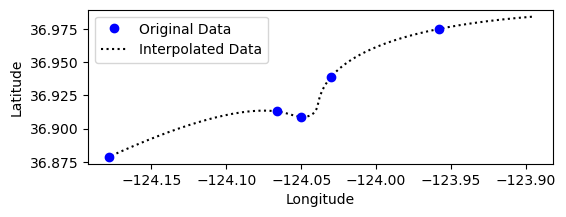

In [7]:
# interpolate eddy core position 
ds = xr.open_dataset('dopplerscatt_gridded.nc')
ds = ds.sel(time=slice('2023-04-19','2023-04-23'), lat=slice(36.7,37.1), lon=slice(-124.25,-123.8))

lats_slice = [slice(36.9,37), slice(36.9,37), slice(36.85,36.95), slice(36.85,36.95), slice(36.85,36.9)]
lons_slice = [slice(-124,-123.9), slice(-124.1,-124), slice(-124.1,-124,), slice(-124.1,-124.0), slice(-124.2,-124.1)]

max_vor_lats = []
max_vor_lons = []
max_vor_times= []

for i in range(ds.sizes['time']):
    dsi = ds.vorticity.isel(time=i).sel(lat=lats_slice[i],lon=lons_slice[i])
    max_vor = dsi.where(dsi==dsi.max(), drop=True).squeeze()
    max_vor_lats.append(max_vor.lat)
    max_vor_lons.append(max_vor.lon)
    max_vor_times.append(dsi.time.values)

    #plt.figure()
    #ds.vorticity.isel(time=i).plot()
    #plt.plot(max_vor.lon, max_vor.lat, 'ok')

# Convert lists to arrays
max_vor_lats = np.array(max_vor_lats)
max_vor_lons = np.array(max_vor_lons)
max_vor_times = np.array(max_vor_times)

# Create DataArrays
lat_da = xr.DataArray(max_vor_lats, coords=[max_vor_times], dims=['time'], name='lat')
lon_da = xr.DataArray(max_vor_lons, coords=[max_vor_times], dims=['time'], name='lon')

# Combine into a Dataset
ds_max_vorticity = xr.Dataset({'lat': lat_da, 'lon': lon_da})

# Interpolate to hourly timestamps
start_time = pd.Timestamp(str(ds_max_vorticity.time.min().values)) - pd.Timedelta(days=0.5)
end_time = pd.Timestamp(str(ds_max_vorticity.time.max().values))

hourly_times = pd.date_range(start=start_time, end=end_time, freq='0.3h')
hourly_times

ds_max_vorticity['time'] = pd.to_datetime(ds_max_vorticity['time'].values)

# Interpolate to hourly timestamps
ds_interpolated = ds_max_vorticity.interp(time=hourly_times, method='quadratic', kwargs={"fill_value": "extrapolate"})

# Plotting the interpolated positions
plt.figure(figsize=(6,2))
plt.plot(ds_max_vorticity['lon'], ds_max_vorticity['lat'], 'bo', label='Original Data',zorder=101)
plt.plot(ds_interpolated['lon'], ds_interpolated['lat'], 'k:', label='Interpolated Data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

#plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/eddy/eddy-core-location-interpolation.png',dpi=800)
plt.show()


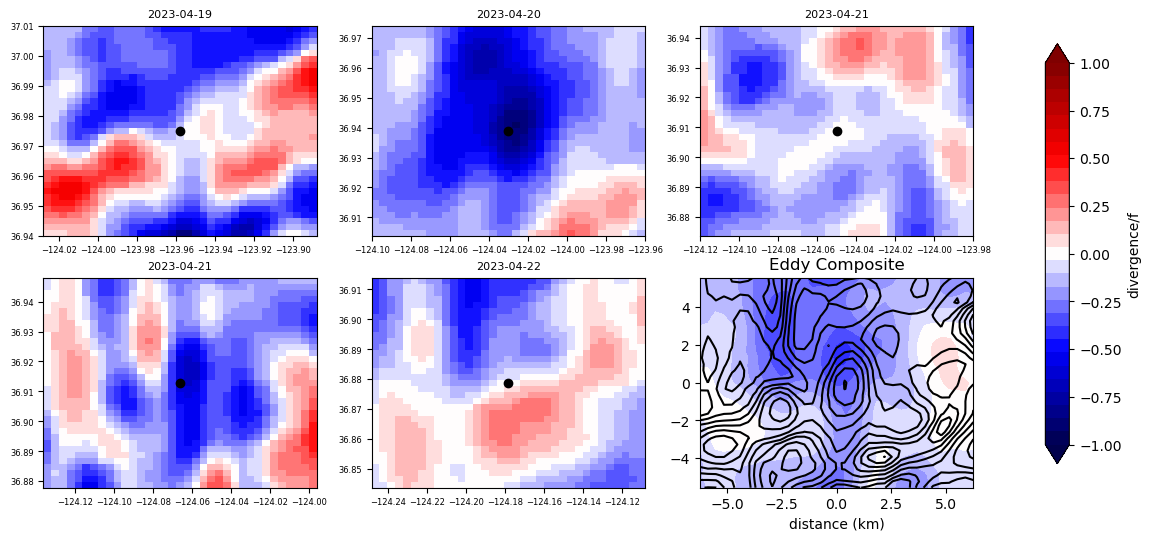

In [8]:
# create eddy composite
var = 'divergence'
if var=='divergence': vmin,vmax=-1,1
elif var=='vorticity': vmin,vmax=-2,2
elif var=='w_ek': vmin,vmax=-3e-4,3e-4; itimes=[11,12,13,14,15]
elif var=='okuboweiss': vmin,vmax=-4e-4,4e-4;

cmap='seismic'

eddy_mid_value=[]
eddy_all = []

fig, ax = plt.subplots(2,3,figsize=(12,6))

for i in range(ds.sizes['time']):
    if var=='w_ek':
        dsi = xr.open_dataset('dopplerscatt_w_ekman_gridded.nc').isel(time=itimes[i]).w_tot
    else: 
        f=coriolis_parameter(35)
        dsi = ds[var].isel(time=i)/f
    lat=ds_max_vorticity.isel(time=i).lat
    lon=ds_max_vorticity.isel(time=i).lon

    f = coriolis_parameter(35)

    dlat,dlon=0.05,0.07
    eddy = dsi.sel(lat=slice(lat-dlat,lat+dlat),lon=slice(lon-dlon,lon+dlon))
    eddy = eddy[7:-7,:]
    eddy_all.append(eddy)
        
    # keep divergence value
    L=len(eddy)
    mid = int(np.round(L/2))
    eddy_mid_value.append(eddy[mid,mid].values)
    
    # plot each eddy
    axis=ax.flatten()[i]
    eddy.plot(levels=np.linspace(vmin,vmax,30), cmap=cmap, extend='both', add_colorbar=False, ax=axis)
    axis.plot(dsi.sel(lat=lat,lon=lon).lon, dsi.sel(lat=lat,lon=lon).lat, 'ok')
    axis.set_title(str(eddy.time.values)[0:10],fontsize=8)
    axis.tick_params(axis='x', labelsize=6); axis.tick_params(axis='y', labelsize=6);
    axis.set_xlabel(''); axis.set_ylabel('')

eddy_all = np.array(eddy_all)
eddy_composite_mean = eddy_all.mean(0)
eddy_composite_std = eddy_all.std(0)

# x/y coordinates of composite
xlat=np.linspace(0,dlat*2,len(eddy.lat))
xlon=np.linspace(0,dlon*2,len(eddy.lon))
y_eddy = xlat * 111320 / 1e3
lat_midpoint = (eddy.lat[0] + eddy.lat[-1]) / 2  # Use the midpoint latitude for conversion
x_eddy = xlon * (111320 * np.cos(np.radians(lat_midpoint.values))) / 1e3

# plot eddy composite
axis=ax.flatten()[-1]
p=axis.contourf(x_eddy-np.mean(x_eddy),y_eddy-np.mean(y_eddy),eddy_composite_mean,np.linspace(vmin,vmax,30),cmap=cmap,extend='both')
axis.contour(x_eddy-np.mean(x_eddy),y_eddy-np.mean(y_eddy),eddy_composite_std,10,colors='k')
axis.set_title('Eddy Composite')
axis.set_xlabel('distance (km)')

cbar_ax = fig.add_axes([0.96, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar=fig.colorbar(p, cax=cbar_ax)
cbar.set_ticks(np.linspace(vmin,vmax,9))
if var=='w_ek': cbar.set_label(f'{var}')
else: cbar.set_label(f'{var}/f')

#plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/eddy/composite-{var}.png',dpi=800)

plt.show();

In [9]:
if var == 'w_ek': w_ek = eddy_composite_mean
if var == 'vorticity': vor = eddy_composite_mean
if var == 'divergence': div = eddy_composite_mean
if var == 'okuboweiss': ow = eddy_composite_mean

In [10]:
create_dataset=0
if create_dataset:
    dataset = xr.Dataset(
    {
    'x_eddy': xr.DataArray(x_eddy - x_eddy.mean(),dims='x_eddy'),
    'y_eddy': xr.DataArray(y_eddy - y_eddy.mean(),dims='y_eddy'),
    'w_ek_eddy':   xr.DataArray(w_ek,dims=('x_eddy','y_eddy')),
    'vor_eddy':   xr.DataArray(vor,dims=('x_eddy','y_eddy')),
    'div_eddy':   xr.DataArray(div,dims=('x_eddy','y_eddy')),
    'ow_eddy':   xr.DataArray(ow,dims=('x_eddy','y_eddy')),
    },)
    dataset.to_netcdf('composite_eddy_centered.nc')
    dataset#.w_ek_eddy.plot()

4696942
4697436
4697439
4697491
4697532
4697629
4697637
4704406


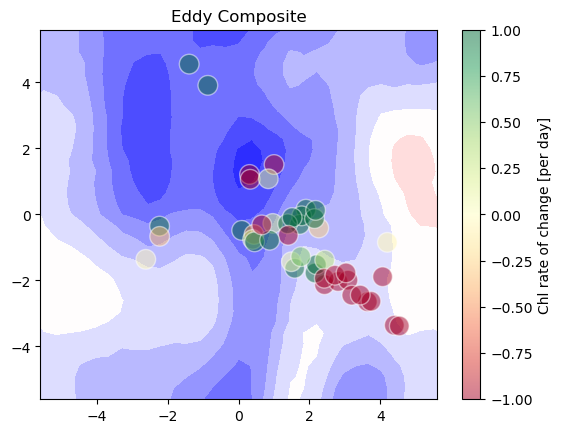

In [11]:
# find max distance of drifter from eddy
#np.warnings.filterwarnings('ignore', category=np.VisibleDeprecationWarning)  
fontsize=10
plt.rcParams["font.size"] = fontsize

dist_from_core = []
dChldt = []
dSSSdt = []
chl    = []
temp   = []
salt   = []
rho    = []
o2sat  = []
time   = []
lat    = []
lon    = []
dist_from_ship = []

#
dx = []
dy = []

#
plot_all=1
plot_individual=0
plot_method=0

if plot_all==1:
    if var=='divergence': vmin,vmax=-1,1
    elif var=='vorticity': vmin,vmax=-2,2
    plt.contourf(x_eddy - x_eddy.mean() , y_eddy - y_eddy.mean(),eddy_composite_mean,
                 np.linspace(vmin,vmax,30),cmap='seismic',extend='both')

IDs=['4696942', '4697436', '4697439', '4697491', '4697532', '4697629', '4697637', '4704406'] # favorites
for ID in IDs:
    print(ID)
    drifter = xr.open_dataset(SMODE_DATA_folder + f'drifters/2023/SMODE_IOP2_surface_drifter_0-{ID}.nc')
    drifter = drifter.isel(time=drifter.position_QCflag==1)

    resample='4h'
    dr = interp_ship_on_drifter_ACS(TSG, drifter, resample, dist=1)
    #dr = interp_ship_on_drifter(uw.resample(time=resample).mean(), drifter, dist=1)
    if len(dr.time)>0:
        dr = dr.resample(time='1h').mean()
    
    T = dr.sizes['time']
    
    # interpolate eddy core position onto drifter timestamp
    ds_interpolated_on_drifter = ds_interpolated.interp(time=dr.time, method='quadratic')
    ds_interpolated_on_drifter = ds_interpolated_on_drifter.ffill('time').bfill('time') # remove nans
    
    # find distance in latitude and longitude for each time step
    dlat = dr.lat - ds_interpolated_on_drifter.lat
    dlon = dr.lon - ds_interpolated_on_drifter.lon
    
    # convert distance into km
    dy_km = dlat * 111320 / 1e3
    dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_drifter.lat.values))) / 1e3
    
    # fill arrays
    dist_from_core.append(np.sqrt(dx_km.values**2 + dy_km.values**2))
    dChldt.append(dr.dChldt.values)            
    #dSSSdt.append(dr.dSSSdt.values)
    chl.append(dr.chl.values)
    #temp.append(dr.temp.values)
    #salt.append(dr.salt.values)
    #rho.append(dr.rho.values)
    #o2sat.append(dr.o2sat.values)
    time.append(dr.time.values) 
    dx.append(dx_km.values)
    dy.append(dy_km.values)
    lat.append(dr.lat)
    lon.append(dr.lon)
    dist_from_ship.append(dr.dist_from_ship)
    
    # plot eddy composite
    if plot_individual==1:
        plt.figure()
        plt.contourf(x_eddy - x_eddy.mean() , y_eddy - y_eddy.mean(), eddy_composite_mean,np.linspace(-2,2,30),cmap='seismic',extend='both')
        p=plt.scatter(dx_km, dy_km, c=dr.dChldt, cmap='RdYlGn', vmin=-1, vmax=1, s=200, alpha=0.5)
        cbar=plt.colorbar(p)
        cbar.set_title('Chl rate of change [per day]')
        plt.title(ID)
        plt.xlabel('radius (km)')
        #plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/eddy/dChldt_eddy-{dr.name}.png',dpi=800)
        plt.show();
        
    if plot_method:
        # plot method
        plt.figure(figsize=(6,5))
        plt.plot(ds_max_vorticity.lon,ds_max_vorticity.lat,'ob',label='dopplerscatt eddy location',zorder=101)
        plt.plot(ds_interpolated.lon,ds_interpolated.lat,':k',label='eddy location interpolated',zorder=101)
        plt.plot(ds_interpolated_on_drifter.lon,ds_interpolated_on_drifter.lat,'o-r',label='eddy on drifter time')
        plt.plot(dr.lon,dr.lat,'ok',label='drifter location')
        plt.plot([ds_interpolated_on_drifter.lon, dr.lon], 
                 [ds_interpolated_on_drifter.lat, dr.lat], 'k--')
        plt.legend()
        plt.title(f'Drifter {dr.name}')
        #plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/eddy/dist_from_core-{dr.name}.png',dpi=800)
        plt.show();

    if plot_all:
        p=plt.scatter(dx_km, dy_km, c=dr.dChldt, cmap='RdYlGn', edgecolor='w', 
                      vmin=-1, vmax=1, s=200, alpha=0.5)

dist_from_ship = np.concatenate(dist_from_ship)
dist_from_core = np.concatenate(dist_from_core)
dChldt = np.concatenate(dChldt)
#dSSSdt = np.concatenate(dSSSdt)
chl = np.concatenate(chl)
#temp = np.concatenate(temp)
#salt = np.concatenate(salt)
#rho = np.concatenate(rho)
#o2sat = np.concatenate(o2sat)
time = np.concatenate(time)
dx = np.concatenate(dx)
dy = np.concatenate(dy)
lat = np.concatenate(lat)
lon = np.concatenate(lon)

if plot_all:
    x=5.6
    plt.xlim(-x,x); plt.ylim(-x,x)
    plt.title('Eddy Composite')
    cbar=plt.colorbar(p)
    cbar.set_label('Chl rate of change [per day]')
    figname=f'composite_{var}_all_dChldt.png'
    #plt.savefig(f'/Users/elise/Desktop/{figname}',dpi=800)
    #plt.savefig(f'/Users/elise/ocean/drifters_chl/high-res/fig3a.pdf)


In [12]:
# only keep non-nan values
idx = ~np.isnan(dist_from_core)

dataset = xr.Dataset(
    {
        'dChldt': ('dist_from_core', dChldt[idx]),
        'chl': ('dist_from_core', chl[idx]),
        'time': ('dist_from_core', time[idx]),
        'lat': ('dist_from_core', lat[idx]),
        'lon': ('dist_from_core', lon[idx]),
        'dist_from_ship': ('dist_from_core', dist_from_ship[idx]),
        'dx': ('dist_from_core', dx[idx]),
        'dy': ('dist_from_core', dy[idx]),
    },
    coords={'dist_from_core': dist_from_core[idx]},
    attrs={'name': 'drifters properties from eddy core'},
    )

dataset = dataset.sortby('dist_from_core')
dataset#.to_netcdf('dChldt_from_core.nc',mode='w')

<xarray.Dataset> Size: 4kB
Dimensions:         (dist_from_core: 53)
Coordinates:
  * dist_from_core  (dist_from_core) float64 424B 0.4888 0.7261 ... 9.125 9.339
Data variables:
    dChldt          (dist_from_core) float64 424B 2.202 -2.095 ... -1.005 -1.169
    chl             (dist_from_core) float64 424B 3.916 2.954 ... 2.556 2.508
    time            (dist_from_core) datetime64[ns] 424B 2023-04-21T15:00:00 ...
    lat             (dist_from_core) float64 424B 36.9 36.9 36.9 ... 36.81 36.81
    lon             (dist_from_core) float64 424B -124.0 -124.1 ... -124.2
    dist_from_ship  (dist_from_core) float64 424B 0.4587 0.5844 ... 0.8588
    dx              (dist_from_core) float64 424B 0.08618 0.6535 ... -5.709
    dy              (dist_from_core) float64 424B -0.4811 -0.3165 ... -7.39
Attributes:
    name:     drifters properties from eddy core

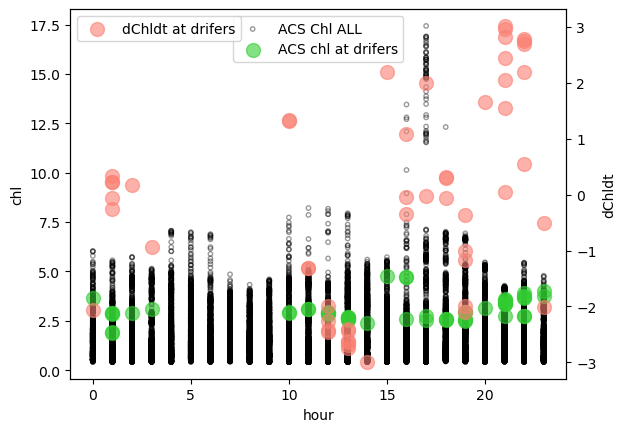

In [13]:
# Diel Cycle
times = TSG['time_bio'] + np.timedelta64(7, 'h')
hour = times.dt.hour# 
plt.scatter(hour,TSG['chlorophyll_ACS'], edgecolor='k', facecolor='None', alpha=0.4, s=10, label='ACS Chl ALL')
#TSG['chlorophyll_ACS'].groupby('time_bio.hour').mean().plot(
#    linestyle='-', linewidth=3, color='limegreen')
plt.ylabel('chl')

# Chlorophyll
times = dataset.time + np.timedelta64(7, 'h')
hour = times.dt.hour

plt.scatter(hour, dataset.chl.values, color='limegreen', alpha=0.6, s=100, label='ACS chl at drifers')
plt.ylabel('chl')
plt.legend(loc='upper center')
plt.xlabel('hour')

# dChldt
times = dataset.time + np.timedelta64(7, 'h')
hour = times.dt.hour
ax2=plt.gca().twinx()
ax2.scatter(hour, dataset.dChldt.values, color='salmon', alpha=0.6, s=100, label='dChldt at drifers')
ax2.set_ylabel('dChldt')

plt.legend()

ax2.set_xlabel('time (hour)')
plt.show();



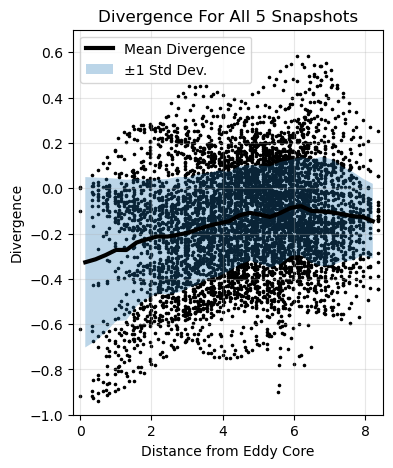

In [14]:
# ALL DIVERGENCE POINTS

# Coordinates deviation from eddy core
dx_eddy = x_eddy - x_eddy.mean()
dy_eddy = y_eddy - y_eddy.mean()
X, Y = np.meshgrid(dx_eddy, dy_eddy)
distances = np.sqrt(X**2 + Y**2).flatten()  # shape (len(x_eddy)*len(y_eddy),)

# Flatten divergence data from all 5 snapshots
div_all = eddy_all.reshape(5, -1)  # shape (5, n_points)
div_all_flat = div_all.flatten()         # shape (5*n_points,)
distances_all = np.tile(distances, 5)    # repeat distances 5 times to match

# Bin by distance
bin_edges = np.linspace(0, distances.max(), 30)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
digitized = np.digitize(distances_all, bin_edges)

# Compute mean and std for each bin
mean_div = np.array([div_all_flat[digitized == i].mean() for i in range(1, len(bin_edges))])
std_div = np.array([div_all_flat[digitized == i].std() for i in range(1, len(bin_edges))])

# Plot
plt.figure(figsize=(4,5))
plt.plot(bin_centers, mean_div, c='k', linewidth=3, label='Mean Divergence')
for i in range(5): plt.scatter(distances,eddy_all[i,...].flatten(),c='k',s=10, marker='.')
plt.fill_between(bin_centers, mean_div - std_div, mean_div + std_div, alpha=0.3, label='±1 Std Dev.')
plt.xlabel('Distance from Eddy Core')
plt.ylabel('Divergence')
plt.title('Divergence For All 5 Snapshots')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(-0.2,8.5); plt.ylim(-1,0.7)
plt.show()


In [15]:
time=ds['divergence'].time.values
eddy_div_all_dataset = xr.Dataset(
    {
        'divergence': (['time','x_eddy','y_eddy'], eddy_all),
    },
    coords={'time': time, 'x_eddy': x_eddy-x_eddy.mean(), 'y_eddy': y_eddy-y_eddy.mean()},
    attrs={'name': 'Eddy divergence of all snapshots'},
    )

#eddy_div_all_dataset = eddy_div_all_dataset.sortby('dist_from_core')
eddy_div_all_dataset#.to_netcdf('eddy_div_all.nc',mode='w')

<xarray.Dataset> Size: 50kB
Dimensions:     (time: 5, x_eddy: 35, y_eddy: 35)
Coordinates:
  * time        (time) <U29 580B '2023-04-19T20:25:05.000000000' ... '2023-04...
  * x_eddy      (x_eddy) float64 280B -6.233 -5.867 -5.5 ... 5.5 5.867 6.233
  * y_eddy      (y_eddy) float64 280B -5.566 -5.239 -4.911 ... 4.911 5.239 5.566
Data variables:
    divergence  (time, x_eddy, y_eddy) float64 49kB 0.0553 0.08333 ... 0.05316
Attributes:
    name:     Eddy divergence of all snapshots

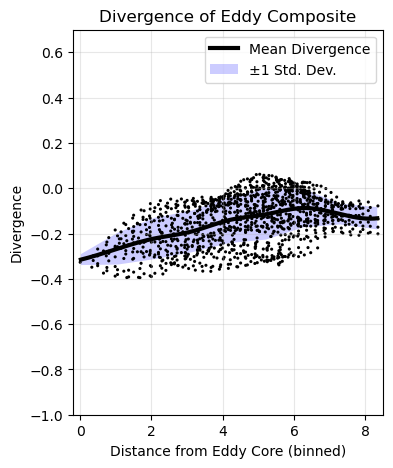

In [16]:
# Divergence deviation from the mean (eddy core)
dx_eddy = x_eddy - x_eddy.mean()
dy_eddy = y_eddy - y_eddy.mean()

# Calculate the distance from the eddy core for each point
X, Y = np.meshgrid(dx_eddy,dy_eddy)
dist_from_eddy_core = np.sqrt(X**2 + Y**2).flatten()

# Flatten the arrays to work with them more easily
distances = dist_from_eddy_core.flatten()
divergences = eddy_composite_mean.flatten()

# Define the bins (e.g., every 10 units of distance)
bin_edges = np.linspace(-0.5, np.max(distances)+0.5, 10)
bin_indices = np.digitize(distances, bin_edges)

# Calculate the mean and standard deviation of divergence for each bin
mean_divergence_by_distance = []
std_divergence_by_distance = []

for i in range(1, len(bin_edges)):
    bin_values = divergences[bin_indices == i]
    if len(bin_values) > 0:
        mean_divergence_by_distance.append(bin_values.mean())
        std_divergence_by_distance.append(bin_values.std())
    else:
        mean_divergence_by_distance.append(np.nan)
        std_divergence_by_distance.append(np.nan)

# Convert lists to arrays for easier handling in plotting
mean_divergence_by_distance = np.array(mean_divergence_by_distance)
std_divergence_by_distance = np.array(std_divergence_by_distance)

# Plot the mean divergence with an envelope of ±1 standard deviation
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

from scipy.ndimage import gaussian_filter1d
smooth_mean = gaussian_filter1d(mean_divergence_by_distance, sigma=100, mode='nearest')
smooth_std = gaussian_filter1d(std_divergence_by_distance, sigma=100, mode='nearest')  # Adjust sigma for smoothing strength

plt.figure(figsize=(4,5))
#plt.plot(bin_centers, mean_divergence_by_distance, c='k', linewidth=3, label='Mean Divergence')

# smooth
x,y = np.array(bin_centers),np.array(mean_divergence_by_distance)
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = scipy.interpolate.make_interp_spline(x, y, k=3)  # k=3 for cubic spline
y_smooth = spline(x_smooth)
plt.plot(x_smooth, y_smooth, c='k', linewidth=3, label='Mean Divergence')

plt.fill_between(bin_centers,
                 mean_divergence_by_distance - std_divergence_by_distance,
                 mean_divergence_by_distance + std_divergence_by_distance,
                 color='b', alpha=0.2, edgecolor='None', label='±1 Std. Dev.')

plt.scatter(dist_from_eddy_core, divergences, color='k', s=20, marker='.', alpha=1, edgecolor='None')
plt.gca().invert_yaxis()
plt.xlabel('Distance from Eddy Core (binned)')
plt.ylabel('Divergence')
plt.title('Divergence of Eddy Composite')
plt.legend()
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.xlim(-0.2,8.5); plt.ylim(-1,0.7)
plt.show()


In [17]:
#div_dataset = xr.Dataset(
#    {
#    'mean_divergence_by_distance': xr.DataArray(mean_divergence_by_distance,dims='dist_from_core'),
#    'dist_from_core': xr.DataArray(bin_centers, dims='dist_from_core'),
#    'div_std': xr.DataArray(std_divergence_by_distance, dims='dist_from_core'),
#    },
#)
#div_dataset.to_netcdf('div_eddy.nc')

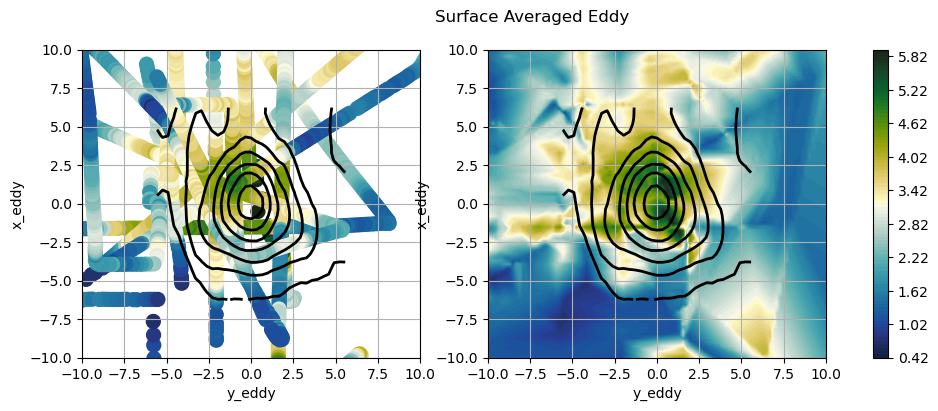

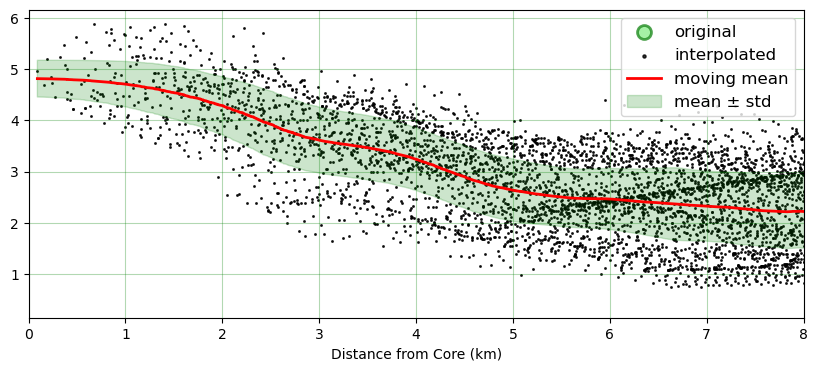

In [18]:
# same for ACS chlorophyll

#####
ACS_eddy_times = TSG['chlorophyll_ACS'].sel(time_bio=slice('2023-04-18','2023-04-23'))

# interpolate eddy core time on uw time
ds_interpolated_on_ACS = ds_interpolated.interp(time=ACS_eddy_times.time_bio, method='quadratic')

# find distance in latitude and longitude for each time step
dlat = ds_interpolated_on_ACS.lat - ACS_eddy_times.latitude_bio
dlon = ds_interpolated_on_ACS.lon - ACS_eddy_times.longitude_bio

# convert distance into km
dy_km = dlat * 111320 / 1e3
dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_ACS.lat.values))) / 1e3
dist_from_core = np.sqrt(dx_km**2 + dy_km**2)

# keep only nighttime values
def is_night(timestamp,delta=-7): #account for photochemical quenching
    # UTC to PST delta=-7
    return (timestamp.dt.hour < 9-delta) | (timestamp.dt.hour >= 17-delta)
idx = (
         (~np.isnan(ACS_eddy_times))
       & (~np.isnan(dy_km))
       & (~np.isnan(dx_km))
       & (ACS_eddy_times<6)

       & (is_night(ACS_eddy_times.time_bio))
    )

dy_km = dy_km[idx]
dx_km = dx_km[idx]

dataset_ship = xr.Dataset(
    {
    'chl': xr.DataArray(ACS_eddy_times.values[idx],dims='dist_from_core'),
    'dist_from_core': xr.DataArray(dist_from_core[idx]),
    },
)
dataset_ship = dataset_ship.sortby('dist_from_core')
dataset_ship


### PLOT ###

fig, ax = plt.subplots(1,2, figsize=(12,4))
p=ax[0].scatter(dx_km, dy_km, c=dataset_ship['chl'],
            s=100, cmap=cm.delta)#, vmin=0, vmax=4)
#plt.colorbar(p,ax=ax[0])
ax[0].set_xlim(-10,10); ax[0].set_ylim(-10,10)
ax[0].grid()

from scipy.interpolate import griddata

# Create grid
xi = np.linspace(dx_km.min(), dx_km.max(), 200)
yi = np.linspace(dy_km.min(), dy_km.max(), 200)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the data onto the grid
zi = griddata((dx_km, dy_km), dataset_ship['chl'], (xi, yi), method='linear')
di = np.sqrt(xi.flatten()**2 + yi.flatten()**2)

# Plot with contourf
p=ax[1].contourf(xi, yi, zi, levels=100, cmap=cm.delta)#, vmin=0, vmax=4)
#plt.colorbar(p,ax=ax[1],label="Chlorophyll")
ax[1].set_xlabel("dx (km)")
ax[1].set_ylabel("dy (km)")
ax[1].set_xlim(-10,10); ax[1].set_ylim(-10,10)
ax[1].grid()
composite_eddy = xr.open_dataset('composite_eddy_centered.nc')
for axis in ax:
    composite_eddy.vor_eddy.plot.contour(levels=np.linspace(-2,2,16),colors='k',linewidths=2,ax=axis)
#(composite_eddy.div_eddy).plot.contour(levels=np.linspace(-2,2,50),colors='k',linewidths=2)

dataset_ship_interpolated = xr.Dataset(
    {
    'chl': xr.DataArray(zi.flatten(),dims='dist_from_core'),
    'dist_from_core': xr.DataArray(di, dims='dist_from_core'),
    },
)
dataset_ship_interpolated = dataset_ship_interpolated.sortby('dist_from_core')

plt.suptitle("Surface Averaged Eddy")
fig.colorbar(p,ax=ax)
plt.show()


# smooth ship chlorophyll from eddy core
data = dataset_ship_interpolated

# Window size for moving mean and std
window_size = 5#500
moving_std = data['chl'].rolling(dist_from_core=window_size, center=True, min_periods=1).std()
moving_mean = data['chl'].rolling(dist_from_core=window_size, center=True, min_periods=1).mean()
# second smoothing round

from scipy.ndimage import gaussian_filter1d
smooth_std_chl = gaussian_filter1d(moving_std, sigma=100, mode='nearest')  # Adjust sigma for smoothing strength
smooth_mean_chl = gaussian_filter1d(moving_mean, sigma=100, mode='nearest')

# Set up the figure

plt.figure(figsize=(10, 4))

# Scatter plot for chlorophyll concentration
#plt.scatter(dataset_ship.dist_from_core, dataset_ship['chl'], s=1, facecolor='lightgreen', edgecolor='forestgreen', 
#            linewidth=2, marker='o', alpha=0.8, zorder=101)
plt.scatter([],[], s=100, facecolor='lightgreen', edgecolor='forestgreen', 
            linewidth=2, marker='o', label='original', alpha=0.8,)
plt.scatter(di,zi, s=5, facecolor='k', edgecolor='k', 
             marker='.', alpha=0.8,)
plt.scatter([],[], s=20, facecolor='k', edgecolor='k', 
             marker='.', label='interpolated', alpha=0.8,)

# Plot the moving mean as an red line
plt.plot(data.dist_from_core, smooth_mean_chl, color='r', label='moving mean', linewidth=2,zorder=101)

plt.fill_between(data.dist_from_core, 
                 smooth_mean_chl - smooth_std_chl, 
                 smooth_mean_chl + smooth_std_chl, 
                 color='g', alpha=0.2, label='mean ± std')

#plt.axhline(0,color='k',linestyle=':')
# Labels, limits, and legend
plt.xlabel('Distance from Core (km)')
#plt.ylabel('Chlorophyll Concentration')
#plt.ylim(-2,6)
plt.legend(fontsize=12,loc='upper right')
plt.xlim(0,8)
#plt.axvline(1,color='k');plt.axvline(2,color='k');plt.axvline(7,color='k')
plt.grid(alpha=0.3,color='g')
plt.show()

# create dataset for composite plot
smooth_mean_chl = xr.Dataset(
    {
    'chl_mean': xr.DataArray(smooth_mean_chl,dims='dist_from_core'),
    'chl_std': xr.DataArray(smooth_std_chl,dims='dist_from_core'),
    'dist_from_core': xr.DataArray(data.dist_from_core.values, dims='dist_from_core'),
    },
)



In [21]:
bio_data

<xarray.Dataset> Size: 2kB
Dimensions:         (dist_from_core: 15)
Coordinates:
  * dist_from_core  (dist_from_core) float64 120B nan nan nan ... 39.52 nan
    time            (dist_from_core) datetime64[ns] 120B ...
Data variables:
    cast            (dist_from_core) float64 120B ...
    depth           (dist_from_core) float64 120B ...
    grazing         (dist_from_core) float64 120B -0.5278 -0.1323 ... -0.2635
    growth          (dist_from_core) float64 120B 0.5545 0.5548 ... 0.9933
    lat             (dist_from_core) float64 120B ...
    lon             (dist_from_core) float64 120B ...
    expt_ID         (dist_from_core) <U11 660B ...
    grazing_se      (dist_from_core) float64 120B ...
    growth_se       (dist_from_core) float64 120B ...
Attributes:
    name:     Growth and Grazing Rates (FCM)

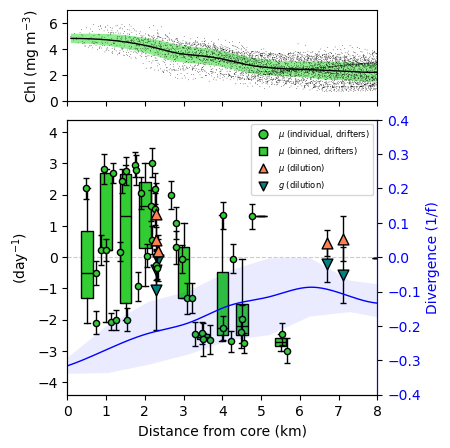

In [33]:
import matplotlib.patches as mpatches
fontsize=10
plt.rcParams["font.size"] = fontsize
plt.rcParams["pdf.fonttype"] = 42

fig, (ax0, ax1) = plt.subplots(2,1,figsize=(4,5),gridspec_kw={'height_ratios': [1, 3],'hspace': 0.1},sharex=True)
plt.rcParams.update({'font.size': 8})

# Chlorophyll (upper plot)
show_chl=1
if show_chl:
    axis=ax0
    color='limegreen'
    line2,=smooth_mean_chl.chl_mean.plot(color='k',linewidth=1,ax=axis,
                                         label='Chlorophyll Concentration')
    x=smooth_mean_chl.dist_from_core; idx=x<9
    axis.fill_between(smooth_mean_chl.dist_from_core[idx], 
                     (smooth_mean_chl.chl_mean-smooth_mean_chl.chl_std)[idx],
                     (smooth_mean_chl.chl_mean+smooth_mean_chl.chl_std)[idx],
                     facecolor='lightgreen', alpha=1, label='Mean ± Std')
    axis.scatter(di,zi, s=1, edgecolor='none', facecolor='k', marker='.', alpha=1)
    axis.set_ylabel(r'Chl (mg m$^{-3}$)')
    axis.set_ylim(0, 7)

# dChldt (Scatter plot)
chl_scatter=1
if chl_scatter:
    axis=ax1
    color='limegreen'
    scatter1 = axis.scatter(dataset.dist_from_core, dataset.dChldt, marker='o', s=20, linewidth=1,
                facecolor=color,edgecolor='k', alpha=1, label='Chlorophyll rate of change',zorder=101)
    dChldt_err = 0.38 * dataset.dist_from_ship + 0.15
    axis.errorbar(dataset.dist_from_core, dataset.dChldt, yerr=dChldt_err, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor=color, ecolor='k', elinewidth=1, capsize=2,zorder=20)
    axis.set_ylabel(r'(day$^{-1})$')
    axis.set_xlabel('Distance from core (km)')
    axis.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)
    
# dChldt (Box plot)
chl_boxplot=1
if chl_boxplot:
    axis=ax1
    color='limegreen'
    width=0.5 #km
    rounded_dfc = np.round(dataset.dist_from_core / width) * width
    unique_rounded_dfc = np.unique(rounded_dfc)
    dChldt_by_dfc_group = [dataset.dChldt[rounded_dfc == dfc] for dfc in unique_rounded_dfc]
    axis.boxplot(dChldt_by_dfc_group, positions=unique_rounded_dfc, widths=0.3, patch_artist=True,
                boxprops=dict(facecolor=color, edgecolor='k'), medianprops=dict(color="k"), whis=(0, 100), zorder=10)
    mpatches.Patch(facecolor=color,edgecolor='k',alpha=0.1,label="Chlorophyll rate of change")    
    axis.set_ylim(-12, 12)
    axis.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8],['0', '1','2','3','4','5','6','7','8'])

# Growth
axis=ax1
color='coral'
bio_data = xr.open_dataset('eddy_biology.nc')
axis.scatter(bio_data.dist_from_core, bio_data.growth, marker='^', s=60, linewidth=1,
            facecolor=color, edgecolor='k', alpha=1, label='Growth rate', zorder=101)
axis.errorbar(bio_data.dist_from_core, bio_data.growth, yerr=bio_data.growth_se+bio_data.growth_se, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor=color, ecolor='k', elinewidth=1, capsize=2,zorder=0)

# Grazing
axis=ax1
color='teal'
axis.scatter(bio_data.dist_from_core, bio_data.grazing, marker='v', s=60, linewidth=1,
            facecolor=color, edgecolor='k', alpha=1, label='Grazing rate')
axis.errorbar(bio_data.dist_from_core, bio_data.grazing, yerr=bio_data.grazing_se+bio_data.growth_se, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor=color, ecolor='k', elinewidth=1, capsize=2,zorder=0)

# Divergence
axis=ax1.twinx()
axis.tick_params(labelsize=fontsize)
axis.yaxis.label.set_size(fontsize)
color='blue'
axis.spines['right'].set_position(('outward', 0))  # Offset
axis.plot(x_smooth, y_smooth, linewidth=1, color=color)
axis.fill_between(bin_centers,
                 mean_divergence_by_distance - std_divergence_by_distance,
                 mean_divergence_by_distance + std_divergence_by_distance,
                 color=color, alpha=0.08, edgecolor='None')#, label='±1 Std. Dev.')
axis.spines['right'].set_color(color)
axis.set_ylabel('Divergence (1/f)', color=color)
axis.set_ylim(-0.4, 0.4)
axis.tick_params(axis='y', labelcolor=color)
axis.yaxis.set_ticks_position('right')
axis.yaxis.set_label_position('right')

# combined legend
s=40
scatter1 = plt.scatter([], [], marker='o', s=s, linewidth=1, alpha=1, facecolor='limegreen', edgecolor='k',
                      linestyle='None', label=r'$\mu$ (individual, drifters)')
box1     = plt.scatter([], [], marker='s', s=s, linewidth=1, alpha=1, facecolor='limegreen', edgecolor='k',
                      linestyle='None', label=r'$\mu$ (binned, drifters)')
scatter2 = plt.scatter([], [], marker='^', s=s, linewidth=1, alpha=1, facecolor='coral', edgecolor='k',
                      linestyle='None', label=r'$\mu$ (dilution)')
scatter3 = plt.scatter([], [], marker='v', s=s, linewidth=1, alpha=1, facecolor='teal', edgecolor='k',
                      linestyle='None', label=r'$g$ (dilution)')

handles = [scatter1, box1, scatter2, scatter3]
labels = [h.get_label() for h in handles]
plt.legend(fontsize=6)

# Plot limits
ax1.set_ylim(-4.4,4.4)
    
ax0.set_xlim(0, 8); ax0.set_xlabel('')
ax1.set_xlim(0, 8)

#plt.savefig('/Users/elise/ocean/drifters_chl/high-res/fig3/fig3bc_newdata.pdf', bbox_inches='tight')#, transparent=True)
plt.show()

In [39]:
bio_data.growth.sortby('dist_from_core')

<xarray.DataArray 'growth' (dist_from_core: 15)> Size: 120B
array([1.381928, 0.537571, 0.194726, 0.442634, 0.59234 , 0.529847, 0.613364,
       0.554543, 0.554824, 0.212076, 0.503858, 0.419249, 0.350155, 1.428814,
       0.993334])
Coordinates:
  * dist_from_core  (dist_from_core) float64 120B 2.287 2.287 2.328 ... nan nan
    time            (dist_from_core) datetime64[ns] 120B ...

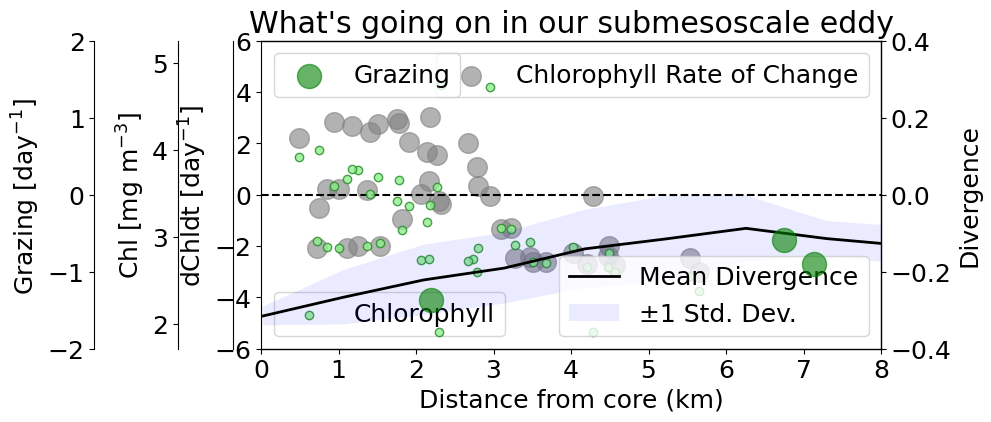

In [1008]:
# OLD
fig, ax1 = plt.subplots(figsize=(8,4))

# dChldt
idx=~np.isnan(dist_from_core)
ax1.scatter(dist_from_core[idx], dChldt[idx], marker='o', s=200, 
            c='grey', alpha=0.6,
            label='Chlorophyll Rate of Change')
ax1.set_ylabel(r'dChldt [day$^{-1}$] ')
ax1.set_xlabel('Distance from core (km)')
ax1.legend(loc='upper right')
ax1.set_ylim(-6,6)
ax1.axhline(0,color='k',linestyle='--')

# Chlorophyll
ax2=ax1.twinx()

ax2.scatter(dist_from_core[idx], chl[idx], facecolor='lightgreen',edgecolor='forestgreen',
            marker='o', label='Chlorophyll', alpha=0.8, zorder=101)
ax2.set_ylabel(r'Chl [mg m$^{-3}$]')
ax2.spines['left'].set_position(('outward', 60))
ax2.set_ylim(np.nanmin(chl)*0.9,np.nanmax(chl)*1.1)
ax2.yaxis.set_ticks_position('left')
ax2.yaxis.set_label_position('left')
ax2.legend(loc='lower left')

# Divergence
ax3 = ax1.twinx()
ax3.spines['left'].set_position(('outward', 20))  # Offset the third axis
ax3.plot(bin_centers, mean_divergence_by_distance, label='Mean Divergence', linewidth=2, color='k')
ax3.fill_between(bin_centers,
                 mean_divergence_by_distance - std_divergence_by_distance,
                 mean_divergence_by_distance + std_divergence_by_distance,
                 color='b', alpha=0.08, edgecolor='None', label='±1 Std. Dev.')
ax3.set_ylabel('Divergence')
ax3.set_ylim(-0.4,0.4)
#ax3.invert_yaxis()
ax3.legend(loc='lower right')

# Grazing
ax4 = ax1.twinx()
ax4.scatter(dist_from_core_grazing, grazing_values, marker='o', s=300, 
            c='g', alpha=0.6,label='Grazing')
ax4.set_ylabel(r'Grazing [day$^{-1}$] ')
ax4.spines['left'].set_position(('outward', 120))
ax4.set_ylim(-2,2)
ax4.yaxis.set_ticks_position('left')
ax4.yaxis.set_label_position('left')
ax4.legend(loc='upper left')

plt.title('What\'s going on in our submesoscale eddy')
#plt.title('Chl, dChldt, dSSSdt, and Divergence with Respect to Distance from Core')

plt.xlim(0,8)
#plt.savefig('/Users/elise/Desktop/distance-from-core.png',dpi=800, bbox_inches='tight')
plt.show()

NameError: name 'dist_from_core_grazing' is not defined

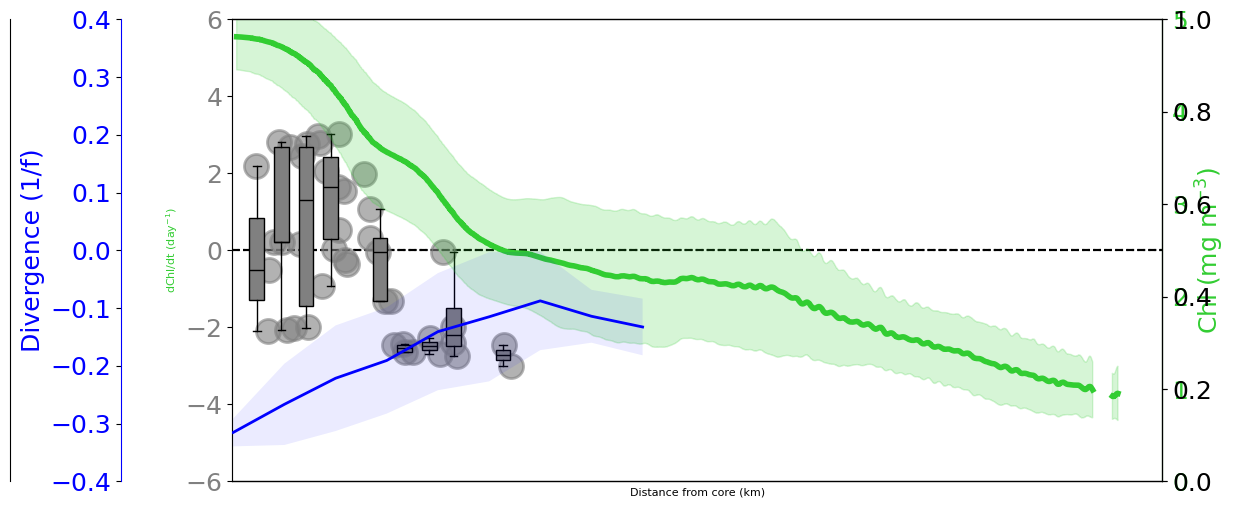

In [48]:
import matplotlib.patches as mpatches

fig, ax1 = plt.subplots(figsize=(12, 6))
plt.rcParams.update({'font.size': 18})

# dChldt (Scatter plot)
chl_scatter=1
if chl_scatter:
    color='grey'
    scatter1 = ax1.scatter(dataset.dist_from_core, dataset.dChldt, marker='o', s=300, linewidth=2,
                c=color, alpha=0.6, label='Chlorophyll rate of change',zorder=101)
    ax1.set_ylabel(r'dChl/dt (day$^{-1}$)', color='limegreen')
    ax1.set_xlabel('Distance from core (km)')
    #ax1.legend(loc='upper right')
    ax1.set_ylim(-6, 6)
    ax1.axhline(0, color='k', linestyle='--')
    ax1.spines['left'].set_position(('outward', 0))
    ax1.spines['left'].set_color(color)
    ax1.tick_params(axis='y', labelcolor=color)

# dChldt (Box plot)
chl_boxplot=1
if chl_boxplot:
    color='grey'
    # dChldt (Box plot)
    rounded_dfc = np.round(dataset.dist_from_core / 0.5) * 0.5
    unique_rounded_dfc = np.unique(rounded_dfc)
    dChldt_by_dfc_group = [dataset.dChldt[rounded_dfc == dfc] for dfc in unique_rounded_dfc]
    ax1.boxplot(dChldt_by_dfc_group, positions=unique_rounded_dfc, widths=0.3, patch_artist=True,
                boxprops=dict(facecolor="grey", color="black"),
                medianprops=dict(color="black"),zorder=101)
    scatter1 = mpatches.Patch(facecolor=color,edgecolor='k',label="Chlorophyll rate of change")    
    ax1.axhline(0, color='k', linestyle=':')
    ax1.set_ylim(-6, 6)
    ax1.axhline(0, color='k', linestyle='--')
    ax1.spines['left'].set_position(('outward', 0))
    ax1.spines['left'].set_color(color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks([])

# Chlorophyll
show_chl=1
if show_chl:
    color='limegreen'
    ax2 = ax1.twinx()
    line2,=smooth_mean_chl.chl_mean.plot(color=color,linewidth=4,ax=ax2,
                                         label='Chlorophyll Concentration',
                                         zorder=0)
    ax2.fill_between(smooth_mean_chl.dist_from_core, 
                     smooth_mean_chl.chl_mean-smooth_mean_chl.chl_std,
                     smooth_mean_chl.chl_mean+smooth_mean_chl.chl_std,
                     color=color, alpha=0.2, label='Mean ± Std')
    #scatter2 = ax2.scatter(dataset.dist_from_core, dataset.chl, s=100, facecolor=color, edgecolor='forestgreen', linewidth=2,
    #            marker='o', label='Chlorophyll concentration', alpha=0.8, zorder=101)
    #line2, = ax2.plot(dataset.dist_from_core, dataset.chl
    ax2.set_ylabel(r'Chl (mg m$^{-3}$)', color=color)
    ax2.spines['right'].set_position(('outward', 0))  # Offset right
    ax2.spines['right'].set_color(color)
    ax2.set_ylim(0, 5)
    ax2.tick_params(axis='y', labelcolor=color)
    #ax2.legend(loc='lower left')
    
# Divergence
color='blue'
ax3 = ax1.twinx()
ax3.spines['left'].set_position(('outward', 80))  # Offset
line3, = ax3.plot(bin_centers, mean_divergence_by_distance, label='Divergence', linewidth=2, color=color)
line3_ = ax3.fill_between(bin_centers,
                 mean_divergence_by_distance - std_divergence_by_distance,
                 mean_divergence_by_distance + std_divergence_by_distance,
                 color=color, alpha=0.08, edgecolor='None', label='±1 Std. Dev.')
#ax3.plot(bin_centers, mean_divergence_by_distance - std_divergence_by_distance, color='grey', alpha=0.3, linestyle='-')
#ax3.plot(bin_centers, mean_divergence_by_distance + std_divergence_by_distance, color='grey', alpha=0.3, linestyle='-')
ax3.spines['left'].set_color(color)
ax3.set_ylabel('Divergence (1/f)', color=color)
ax3.set_ylim(-0.4, 0.4)
ax3.tick_params(axis='y', labelcolor=color)
#ax3.legend(loc='lower right')
ax3.yaxis.set_ticks_position('left')
ax3.yaxis.set_label_position('left')
#ax3.set_xticks([np.linspace(0,10,0.5)])

# Grazing
ax4 = ax1.twinx()
ax4.spines['left'].set_position(('outward', 160))  # Offset
scatter4 = ax4.scatter(dist_from_core_grazing, grazing_values, marker='o', s=300, linewidth=2,
            c='g', alpha=0.6, label='Grazing rate')
ax4.set_ylabel(r'Grazing rate (day$^{-1}$)', color='g')
ax4.set_ylim(-2, 2)
ax4.tick_params(axis='y', labelcolor='g')
#ax4.legend(loc='upper left')
ax4.yaxis.set_ticks_position('left')
ax4.yaxis.set_label_position('left')

# combined legend
handles = [scatter1, scatter4, line3, line2]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper right')

plt.title('What\'s going on in our submesoscale eddy')
plt.xlim(0, 8)
#plt.savefig('/Users/elise/Desktop/fig4b.png',dpi=800, bbox_inches='tight')
plt.show()

## SURFACE COMPOSITE

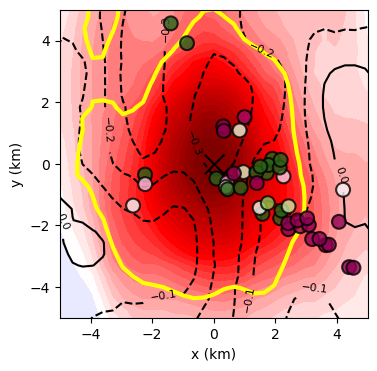

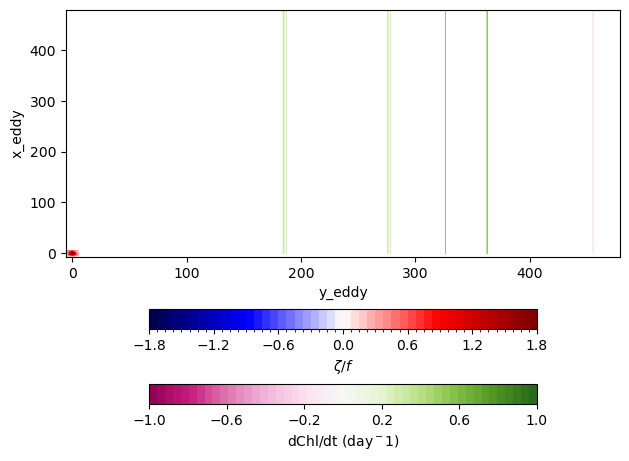

In [229]:
composite_eddy = xr.open_dataset('composite_eddy_centered.nc')
fontsize=10
plt.rcParams["font.size"] = fontsize
plt.rcParams["pdf.fonttype"] = 42

fig, ax = plt.subplots(1,1,figsize=(4,4))

# Vorticity Contour Map
p_vor=composite_eddy.vor_eddy.plot.contourf(cmap='seismic',levels=np.linspace(-1.8,1.8,49),add_colorbar=False)

# Divergence Contours
contour = (composite_eddy.div_eddy).plot.contour(levels=np.unique(np.round(np.linspace(-2,2,50),1)),
                                                 colors='k',linewidths=1.5)
plt.clabel(contour, inline=True, fontsize=8)

# Okubo-Weiss Parameter
composite_eddy.ow_eddy.plot.contour(levels=[0],colors='yellow',linewidths=3)

#composite_eddy.w_ek_eddy.plot.contour(levels=18,cmap='seismic',linewidths=2)

plt.scatter(0,0 , marker='x',c='k',s=200,zorder=101)

p_dchl=plt.scatter(dx, dy, c=dChldt, cmap='PiYG',vmin=-1, vmax=1, s=100, alpha=0.8, edgecolor='k', linewidth=1.5, zorder=101)

# plot features
fs=10
plt.xticks(fontsize=fs); plt.yticks(fontsize=fs)
plt.xlabel('x (km)',fontsize=fs); plt.ylabel('y (km)',fontsize=fs)
x=5; plt.xlim(-x,x); plt.ylim(-x,x)

ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
#plt.savefig('/Users/elise/Desktop/eddy_composite.png',dpi=800, bbox_inches='tight')
#plt.savefig('/Users/elise/ocean/drifters_chl/high-res/fig3a.pdf')

plt.show()


# colorbars
plt.rcParams["pdf.fonttype"] = 42
fig, ax = plt.subplots(1,1)
p_vor=composite_eddy.vor_eddy.where(composite_eddy.vor_eddy<1.8,np.nan).plot.contourf(cmap='seismic',levels=np.linspace(-1.8,1.8,49),add_colorbar=False)

data=np.array((np.meshgrid(dChldt,dChldt)))[0,...]
data=xr.DataArray(data,dims=['lat','lon']).where(data<2,np.nan)
p_dchl=plt.contourf(data, levels=np.linspace(-1,1,50),cmap='PiYG',)

cbar2=plt.colorbar(p_dchl,ax=ax,orientation='horizontal',pad=0.05, extend='both',shrink=0.7)
cbar1=plt.colorbar(p_vor,ax=ax,orientation='horizontal', extend=None,shrink=0.7)

cbar1.set_label(r'$\zeta/f$',fontsize=fs);
cbar1.set_ticks(np.linspace(-1.8,1.8,7))
cbar2.set_label('dChl/dt (day$^-1$)',fontsize=fs)
cbar2.set_ticks(np.linspace(-1,1,6))
plt.savefig('/Users/elise/ocean/drifters_chl/high-res/fig3a-cbars.pdf')

plt.tight_layout()
plt.show()


In [175]:
# only keep non-nan values
idx = ~np.isnan(dist_from_core)

dataset_time = xr.Dataset(
    {
        'dChldt': ('time', dChldt[idx]),
        'chl': ('time', chl[idx]),
        'dist_from_core': ('time', dist_from_core[idx]),
        'lat': ('time', lat[idx]),
        'lon': ('time', lon[idx]),
        'dx': ('time', dx[idx]),
        'dy': ('time', dy[idx]),
    },
    coords={'time': time[idx]},
    attrs={'name': 'drifters properties from eddy core'},
    )

dataset_time = dataset_time.sortby('time')
dataset_time#.to_netcdf('dChldt_from_core.nc',mode='w')

<xarray.Dataset> Size: 3kB
Dimensions:         (time: 53)
Coordinates:
  * time            (time) datetime64[ns] 424B 2023-04-19T03:00:00 ... 2023-0...
Data variables:
    dChldt          (time) float64 424B 1.316 1.337 2.194 ... -1.005 -0.3603
    chl             (time) float64 424B 2.932 2.888 4.777 ... 2.508 2.556 2.581
    dist_from_core  (time) float64 424B 4.765 4.008 2.258 ... 9.339 9.125 8.41
    lat             (time) float64 424B 37.02 37.02 36.98 ... 36.81 36.81 36.81
    lon             (time) float64 424B -123.9 -123.9 -123.9 ... -124.2 -124.2
    dx              (time) float64 424B -1.396 -0.8686 -2.23 ... -5.258 -3.906
    dy              (time) float64 424B 4.557 3.913 -0.3537 ... -7.458 -7.448
Attributes:
    name:     drifters properties from eddy core

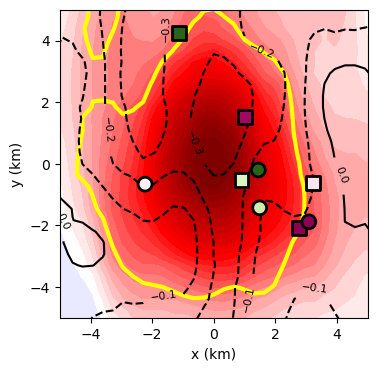

In [230]:
# dChldt 12h
grouped_12h = dataset_time.resample(time='12h', offset='6h')
median_12h = grouped_12h.median()
stderr_12h = grouped_12h.std() / np.sqrt(grouped_12h.count())
median_12h['time'] = median_12h['time'] + np.timedelta64(6, 'h')
#dChldt_err = 0.38 * median_12h.dist_from_ship + 0.15
#plt.scatter(median_12h.time, median_12h.dChldt, s=100, marker='o', edgecolor='k', facecolor='limegreen', zorder=101)
#plt.errorbar(median_12h.time.values, median_12h.dChldt.values, yerr=dChldt_err.values, fmt='none', 
#             markersize=5, markerfacecolor='none', markeredgecolor='limegreen', 
#             ecolor='k', elinewidth=1, capsize=2, zorder=0)

fig, ax = plt.subplots(1,1,figsize=(4,4))

# Color per daytime/nighttime
hours_bool=(median_12h.time.dt.hour==12)*1
two_colors=['darkblue','orange']
two_symbols=['s','o']
daynight_colors = []
daynight_symbols = []
for i in range(len(hours_bool)):
    daynight_colors.append(two_colors[hours_bool[i].values])
    daynight_symbols.append(two_symbols[hours_bool[i].values])
#p_dchl=plt.scatter(dataset_time.dx, dataset_time.dy, 
#                   c=dataset_time.dChldt, cmap='PiYG',
#                   vmin=-1, vmax=1, s=100, alpha=0.1, 
#                   edgecolor='k', linewidth=1.5, zorder=101)

# Boolean array: True = day, False = night
is_day = hours_bool.values  # or np.array if needed

# First subset: day
plt.scatter(median_12h.dx[hours_bool==0], median_12h.dy[hours_bool==0],
            c=median_12h.dChldt[hours_bool==0], cmap='PiYG',
            vmin=-1, vmax=1, s=100, alpha=1,
            marker='s', edgecolor='k', linewidth=2, zorder=101,)

# Second subset: night
plt.scatter(median_12h.dx[hours_bool==1], median_12h.dy[hours_bool==1],
            c=median_12h.dChldt[hours_bool==1], cmap='PiYG',
            vmin=-1, vmax=1, s=100, alpha=1,
            marker='o', edgecolor='k', linewidth=2, zorder=101,)


p_vor=composite_eddy.vor_eddy.plot.contourf(
                    cmap='seismic',levels=np.linspace(-1.8,1.8,49),
                    add_colorbar=False)
composite_eddy.ow_eddy.plot.contour(levels=[0],colors='yellow',linewidths=3)
contour = (composite_eddy.div_eddy).plot.contour(levels=np.unique(np.round(np.linspace(-2,2,50),1)),
                                                 colors='k',linewidths=1.5)
plt.clabel(contour, inline=True, fontsize=8)

fs=10
plt.xticks(fontsize=fs); plt.yticks(fontsize=fs)
plt.xlabel('x (km)',fontsize=fs); plt.ylabel('y (km)',fontsize=fs)
x=5; plt.xlim(-x,x); plt.ylim(-x,x)
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
#plt.savefig('/Users/elise/Desktop/eddy_composite.png',dpi=800, bbox_inches='tight')
plt.savefig('/Users/elise/ocean/drifters_chl/high-res/fig3a.pdf')

plt.show()


## Quality Control

In [ ]:
#for i in range(len(dist_from_core)):
#    d=dist_from_core[i]
#    v=dChldt[i]
#    t=time[i]
#    print(t,d,v)

#for i in range(len(dr.dChldt)):
#        if dr.dChldt.values[i]==1.3162168051094507:
#            print('--- HERE --------')
#            print(f'dChldt = {dr.dChldt.values[i]}')
#            print(f'dist_from_core = {(np.sqrt(dx_km.values**2 + dy_km.values**2))[i]}')
#            print(f'dx_km,dy_km = {dx_km[i].values,dy_km[i].values}')
#            print(f'dlon,dlat = {dlon[i].values,dlat[i].values}')
#            print(f'dr_lon,dr_lat = {dr.lon[i].values,dr.lat[i].values}')
#            print(f'ds_lon,ds_lat = {ds_interpolated_on_drifter.lon[i].values,ds_interpolated_on_drifter.lat[i].values}')
#            print('-----------------')

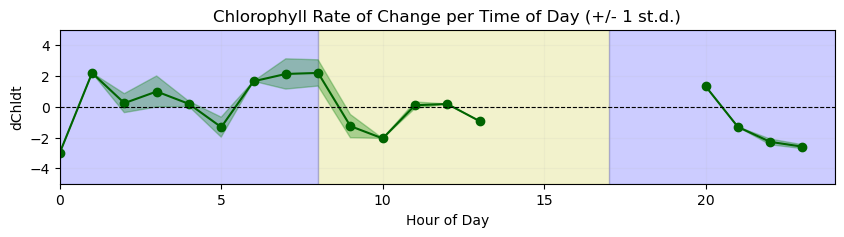

In [93]:
# Chlorophyll rate of change by time of day
# note that ASG is in UTC time

dataset = xr.Dataset(
    {
    'time': xr.DataArray(time-np.timedelta64(7, 'h'),dims='time'),
    'dChldt': xr.DataArray(dChldt,dims='time'),
    'chl': xr.DataArray(chl,dims='time'),
    },)
dataset

mean = dataset.groupby('time.hour').mean(dim='time')
std = dataset.groupby('time.hour').std(dim='time')
mean.dChldt.plot(marker='o',color='darkgreen',figsize=(10,2))

plt.fill_betweenx([-5,5],8,17,color='y',alpha=0.2) # daytime
plt.fill_betweenx([-5,5],0,8,color='b',alpha=0.2) # nighttime
plt.fill_betweenx([-5,5],17,24,color='b',alpha=0.2) # nighttime

plt.fill_between(mean.hour,(mean+std).dChldt,(mean-std).dChldt,color='g',alpha=0.3)

plt.axhline(0,linestyle='--',color='k',linewidth=0.8)

plt.grid(alpha=0.1)
plt.xlabel('Hour of Day')
plt.xlim(0,24); plt.ylim(-5,5)
plt.title('Chlorophyll Rate of Change per Time of Day (+/- 1 st.d.)');
#plt.plot(dataset.time,dataset.dChldt,'ok')


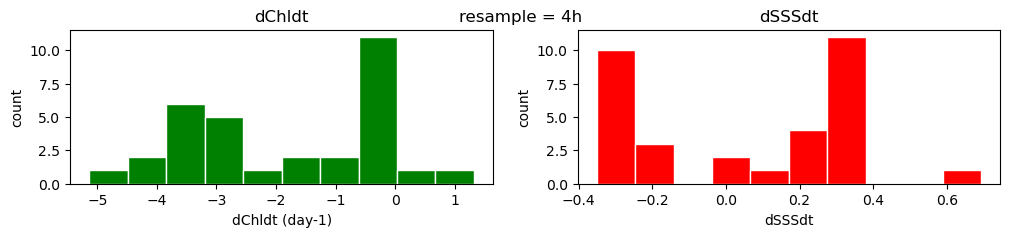

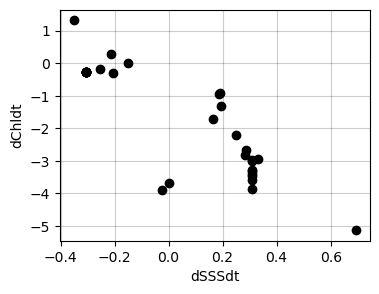

In [20]:
# dChldt, dSSTdt distributions
idx = ~np.isnan(dist_from_core)

fig,ax=plt.subplots(1,2,figsize=(12,2))
axis=ax[0]
axis.hist(dChldt[idx],10,edgecolor='w',facecolor='g');
axis.set_ylabel('count')
axis.set_xlabel('dChldt (day-1)')
axis.set_title('dChldt')

axis=ax[1]
axis.hist(dSSSdt[idx],10,edgecolor='w',facecolor='r');
axis.set_ylabel('count')
axis.set_xlabel('dSSSdt')
axis.set_title('dSSSdt')
plt.suptitle(f'resample = {resample}')
plt.show()

plt.figure(figsize=(4,3))
plt.scatter(dSSSdt[idx],dChldt[idx],color='k')
plt.ylabel('dChldt'); plt.xlabel('dSSSdt')
plt.grid(color='k',alpha=0.2);

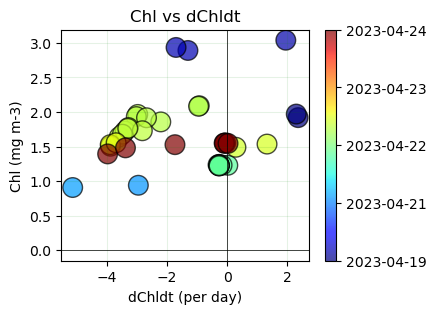

In [197]:
idx=np.argsort(time)

plt.figure(figsize=(4,3))
plt.scatter(dChldt[idx], chl[idx], c=time[idx].astype(float), cmap='jet',
            edgecolor='k', alpha=0.7, s=200)
plt.xlabel('dChldt (per day)')
plt.grid(color='g', alpha=0.1)
plt.ylabel('Chl (mg m-3)')
plt.axhline(0,color='k',linewidth=0.5)
plt.axvline(0,color='k',linewidth=0.5)
cbar=plt.colorbar()
tick_positions = np.linspace(time[idx].min().astype(float), time[idx].max().astype(float), 5)
cbar.set_ticks(tick_positions)
cbar.set_ticklabels([str(t)[:10] for t in time[idx][::len(time[idx])//4]])

plt.title('Chl vs dChldt');

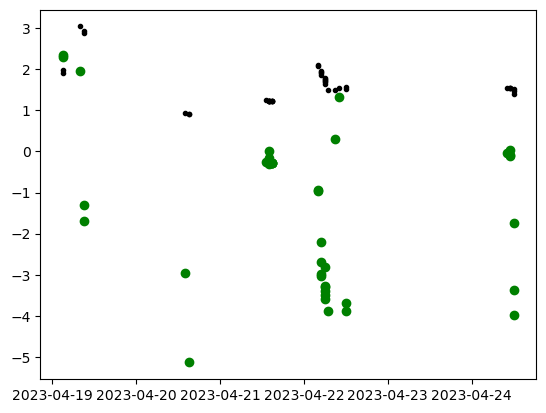

In [133]:
plt.plot(time,dChldt,'og')
plt.plot(time,chl,'.k')

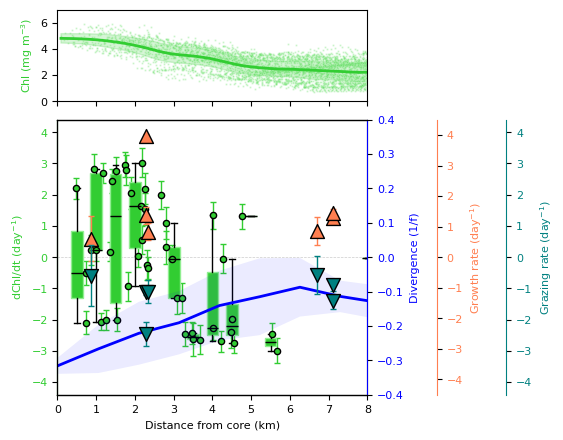

In [70]:
import matplotlib.patches as mpatches

fig, (ax0, ax1) = plt.subplots(2,1,figsize=(4,5),
                               gridspec_kw={'height_ratios': [1, 3],
                                            'hspace': 0.1},
                               sharex=True)
plt.rcParams.update({'font.size': 8})


# dChldt (Box plot)
chl_boxplot=1
if chl_boxplot:
    color='limegreen'
    # dChldt (Box plot)
    width=0.5 #km
    rounded_dfc = np.round(dataset.dist_from_core / width) * width
    unique_rounded_dfc = np.unique(rounded_dfc)
    dChldt_by_dfc_group = [dataset.dChldt[rounded_dfc == dfc] for dfc in unique_rounded_dfc]
    ax1.boxplot(dChldt_by_dfc_group, positions=unique_rounded_dfc, widths=0.3, patch_artist=True,
                boxprops=dict(facecolor="limegreen", color="lightgreen"),
                medianprops=dict(color="k"), whis=(0, 100), zorder=101)
    scatter1 = mpatches.Patch(facecolor=color,edgecolor='k',alpha=0.1,label="Chlorophyll rate of change")    
    ax1.set_ylim(-12, 12)
    ax1.spines['left'].set_position(('outward', 0))
    ax1.spines['left'].set_color(color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8],['0', '1','2','3','4','5','6','7','8'])

# dChldt (Scatter plot)
chl_scatter=1
if chl_scatter:
    color='limegreen'
    scatter1 = ax1.scatter(dataset.dist_from_core, dataset.dChldt, marker='o', s=20, linewidth=1,
                facecolor='limegreen',edgecolor='k', alpha=1, label='Chlorophyll rate of change',zorder=101)
    dChldt_err = 0.38 * dataset.dist_from_ship + 0.15
    ax1.errorbar(dataset.dist_from_core, dataset.dChldt, yerr=dChldt_err, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor='limegreen', ecolor='limegreen', elinewidth=1, capsize=2,zorder=0)

    ax1.set_ylabel(r'dChl/dt (day$^{-1}$)', color=color)
    ax1.set_xlabel('Distance from core (km)')
    ax1.set_ylim(-4, 4)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    ax1.spines['left'].set_position(('outward', 0))
    ax1.spines['left'].set_color(color)
    ax1.tick_params(axis='y', labelcolor=color)
    
# Chlorophyll (upper plot)
show_chl=1
if show_chl:
    color='limegreen'
    ax2 = ax0#.twinx()
    line2,=smooth_mean_chl.chl_mean.plot(color=color,linewidth=2,ax=ax2,
                                         label='Chlorophyll Concentration')
    ax2.fill_between(smooth_mean_chl.dist_from_core, 
                     smooth_mean_chl.chl_mean-smooth_mean_chl.chl_std,
                     smooth_mean_chl.chl_mean+smooth_mean_chl.chl_std,
                     color=color, alpha=0.2, label='Mean ± Std')
    ax2.scatter(di,zi, s=3, facecolor='limegreen', edgecolor='lightgreen', 
             marker='.', alpha=0.2,)
    ax2.set_ylabel(r'Chl (mg m$^{-3}$)', color=color)
    ax2.spines['right'].set_position(('outward', 0))  # Offset right
    ax2.set_ylim(0, 7)

    
# Divergence
color='blue'
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 0))  # Offset
line3, = ax3.plot(bin_centers, mean_divergence_by_distance, label='Divergence', linewidth=2, color=color)
line3_ = ax3.fill_between(bin_centers,
                 mean_divergence_by_distance - std_divergence_by_distance,
                 mean_divergence_by_distance + std_divergence_by_distance,
                 color=color, alpha=0.08, edgecolor='None', label='±1 Std. Dev.')
ax3.spines['right'].set_color(color)
ax3.set_ylabel('Divergence (1/f)', color=color)
ax3.set_ylim(-0.4, 0.4)
ax3.tick_params(axis='y', labelcolor=color)
#ax3.legend(loc='lower right')
ax3.yaxis.set_ticks_position('right')
ax3.yaxis.set_label_position('right')
#ax3.set_xticks([np.linspace(0,10,0.5)])

# Growth
color='coral'
bio_data = xr.open_dataset('eddy_biology.nc')
ax4 = ax1.twinx()
ax4.spines['right'].set_position(('outward', 50))  # Offset
ax4.spines['right'].set_color(color)
scatter4 = ax4.scatter(bio_data.dist_from_core, bio_data.growth, marker='^', s=100, linewidth=1,
            facecolor=color, edgecolor='k', alpha=1, label='Growth rate', zorder=101)
ax4.errorbar(bio_data.dist_from_core, bio_data.growth, yerr=bio_data.growth_se+bio_data.growth_se, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor=color, ecolor=color, elinewidth=1, capsize=2,zorder=0)
ax4.set_ylabel(r'Growth rate (day$^{-1}$)', color=color)
ax4.set_ylim(-4.5,4.5)
ax4.tick_params(axis='y', labelcolor=color)
#ax4.legend(loc='upper left')
ax4.yaxis.set_ticks_position('right')
ax4.yaxis.set_label_position('right')

# Grazing
color='teal'
ax4 = ax1.twinx()
ax4.spines['right'].set_color(color)
ax4.spines['right'].set_position(('outward', 100))  # Offset
scatter4 = ax4.scatter(bio_data.dist_from_core, bio_data.grazing, marker='v', s=100, linewidth=1,
            facecolor=color, edgecolor='k', alpha=1, label='Grazing rate')
ax4.errorbar(bio_data.dist_from_core, bio_data.grazing, yerr=bio_data.grazing_se+bio_data.growth_se, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor=color, ecolor=color, elinewidth=1, capsize=2,zorder=0)
ax4.set_ylabel(r'Grazing rate (day$^{-1}$)', color=color)
ax4.set_ylim(-4.5,4.5)
ax4.tick_params(axis='y', labelcolor=color)
ax4.yaxis.set_ticks_position('right')
ax4.yaxis.set_label_position('right')

# combined legend
handles = [scatter1, scatter4, line3]#, line2]
labels = [h.get_label() for h in handles]
leg1 = plt.Line2D([], [], marker='o', markersize=6, color='lightgreen', linestyle='None', 
                    markerfacecolor='limegreen', alpha=1, label='dChldt')
leg2 = plt.Line2D([], [], linewidth=2, color='blue', label='Divergence')
leg3 = plt.scatter([], [], marker='^', s=100, linewidth=1, alpha=1, facecolor='coral', edgecolor='k',
                  linestyle='None', label='Growth rate')
leg4 = plt.scatter([], [], marker='v', s=100, linewidth=1, alpha=1, facecolor='teal', edgecolor='k',
                  linestyle='None', label='Grazing rate')

handles = [leg1, leg2, leg3, leg4]
labels = [h.get_label() for h in handles]
#ax1.legend(handles, labels, loc='upper center')


# Plot limits
for axis in [ax1, ax4]:
    axis.set_ylim(-4.4,4.4)
    
ax0.set_xlim(0, 8); ax0.set_xlabel('')
ax1.set_xlim(0, 8)

#plt.savefig('/Users/elise/Desktop/distance_from_core.png',dpi=800, bbox_inches='tight')#, transparent=True)
plt.show()

## Ship Chlorophyll from Eddy Core

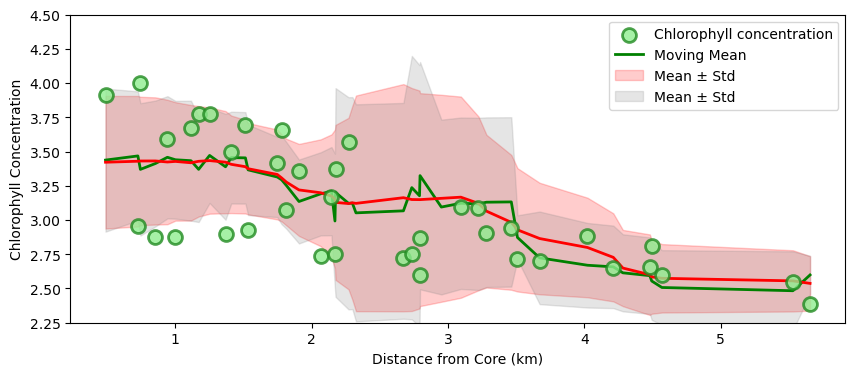

In [62]:
# smooth chlorophyll

# Window size for moving mean and std
window_size = 8
moving_std = dataset.chl.rolling(dist_from_core=window_size, center=True, min_periods=1).std()
moving_mean = dataset.chl.rolling(dist_from_core=window_size, center=True, min_periods=1).mean()
# Set up the figure
plt.figure(figsize=(10, 4))

# Scatter plot for chlorophyll concentration
plt.scatter(dataset.dist_from_core, dataset.chl, s=100, facecolor='lightgreen', edgecolor='forestgreen', 
            linewidth=2, marker='o', label='Chlorophyll concentration', alpha=0.8, zorder=101)

# Plot the moving mean as an orange line
plt.plot(dataset.dist_from_core, moving_mean, color='green', label='Moving Mean', linewidth=2)

smooth_mean_chl=moving_mean.rolling(dist_from_core=8, center=True, min_periods=1).mean()
smooth_std_chl=moving_std.rolling(dist_from_core=8, center=True, min_periods=1).mean()

smooth_mean_chl.plot(color='r',linewidth=2)
plt.fill_between(dataset.dist_from_core, 
                 smooth_mean_chl - smooth_std_chl, 
                 smooth_mean_chl + smooth_std_chl, 
                 color='r', alpha=0.2, label='Mean ± Std')

# Plot the moving standard deviation envelope (mean ± std)
plt.fill_between(dataset.dist_from_core,
                 moving_mean - moving_std,
                 moving_mean + moving_std,
                 color='gray', alpha=0.2, label='Mean ± Std')

# Labels, limits, and legend
plt.xlabel('Distance from Core (km)')
plt.ylabel('Chlorophyll Concentration')
plt.ylim(2.25, 4.5)
plt.legend()
plt.show()


## Grazing around eddy

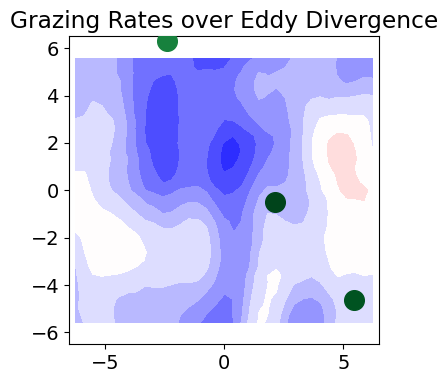

In [97]:
from datetime import timezone
import warnings
warnings.filterwarnings("ignore")

grazing_files = sorted(glob('/Users/elise/Desktop/bio-casts/*.nc'))

# Initialize empty arrays
grazing_values = []
dist_from_core_grazing = []

grazing_casts = xr.open_dataset('grazing_casts.nc')

plt.figure(figsize=(4,4))
for i in range(len(grazing_casts.Cast)):
    cast = grazing_casts.isel(Cast=i)
    
    # interpolate eddy core position onto grazing timestamp
    ds_interpolated_on_grazing = ds_interpolated.interp(time=cast.Time, method='quadratic', kwargs={"fill_value": "extrapolate"})
    
    if (~np.isnan(ds_interpolated_on_grazing.lat)) & (cast.Depth<8):
        # find distance in latitude and longitude for each time step
        dlat = cast.Lat.values - ds_interpolated_on_grazing.lat.values
        dlon = cast.Lon.values - ds_interpolated_on_grazing.lon.values
        
        # convert distance into km
        dy_km = dlat * 111320 / 1e3
        dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_grazing.lat.values))) / 1e3
        
        # fill arrays
        grazing_values.append(cast.Grazing.values)
        dist_from_core_grazing.append(np.sqrt(dx_km**2 + dy_km**2))
        
        #print(f'{cast.depth.values} m depth, {np.round(dist_from_core_grazing,2)} km from eddy core')

        # plot grazing over eddy
        
        p=plt.scatter(dx_km, dy_km,c=cast.Grazing.values, cmap='Greens_r', vmin=-1, vmax=1, s=200, alpha=1,zorder=101)

# plot eddy composite
plt.contourf(x_eddy - x_eddy.mean() , y_eddy - y_eddy.mean(),eddy_composite,
                 np.linspace(vmin,vmax,30),cmap='seismic',extend='both')
s=6.5
plt.xlim(-s,s)
plt.ylim(-s,s)
plt.title('Grazing Rates over Eddy Divergence')

# save grazing arrays
grazing_values = np.array(grazing_values)
dist_from_core_grazing = np.array(dist_from_core_grazing)

## Particulate Organic Carbon

In [739]:
# Particulate Organic Carbon

TSG_eddy_times = TSG.sel(time_bio=slice('2023-04-18','2023-04-21'))
#particulate_organic_carbon_cstar

# interpolate eddy core time on uw time
ds_interpolated_on_uw = ds_interpolated.interp(time=TSG_eddy_times.time_bio, method='quadratic')

# find distance in latitude and longitude for each time step
dlat = ds_interpolated_on_uw.lat - TSG_eddy_times.latitude_bio
dlon = ds_interpolated_on_uw.lon - TSG_eddy_times.longitude_bio

# convert distance into km
dy_km = dlat * 111320 / 1e3
dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_uw.lat.values))) / 1e3
dist_from_core = np.sqrt(dx_km**2 + dy_km**2)

# keep only nighttime values
def is_night(timestamp,delta=-7): #account for photochemical quenching
    # UTC to PST delta=-7
    return (timestamp.dt.hour < 9-delta) | (timestamp.dt.hour >= 17-delta)
idx = (  (is_night(TSG_eddy_times.time_bio)) & (~np.isnan(TSG_eddy_times.particulate_organic_carbon_cstar))
       & (~np.isnan(dy_km)) & (~np.isnan(dx_km))
      )

dy_km = dy_km[idx]
dx_km = dx_km[idx]

dataset_ship = xr.Dataset(
    {
    'POC': xr.DataArray(TSG_eddy_times.particulate_organic_carbon_cstar.values[idx],
                        dims='dist_from_core'),
    'dist_from_core': xr.DataArray(dist_from_core[idx]),
    },
)
dataset_ship = dataset_ship.sortby('dist_from_core')
dataset_ship

<xarray.Dataset> Size: 110kB
Dimensions:         (dist_from_core: 2292, time_bio: 2292)
Coordinates:
    time            (time_bio) datetime64[ns] 18kB 2023-04-19T12:24:00 ... 20...
  * time_bio        (time_bio) datetime64[ns] 18kB 2023-04-19T12:24:00 ... 20...
    latitude_bio    (time_bio) float64 18kB 36.98 36.98 36.98 ... 37.19 37.19
    longitude_bio   (time_bio) float64 18kB -123.9 -123.9 ... -124.2 -124.2
    dist_from_core  (time_bio) float64 18kB 0.4327 0.4431 0.4895 ... 34.85 34.87
Data variables:
    POC             (dist_from_core) float64 18kB 14.61 15.07 ... 9.867 9.798

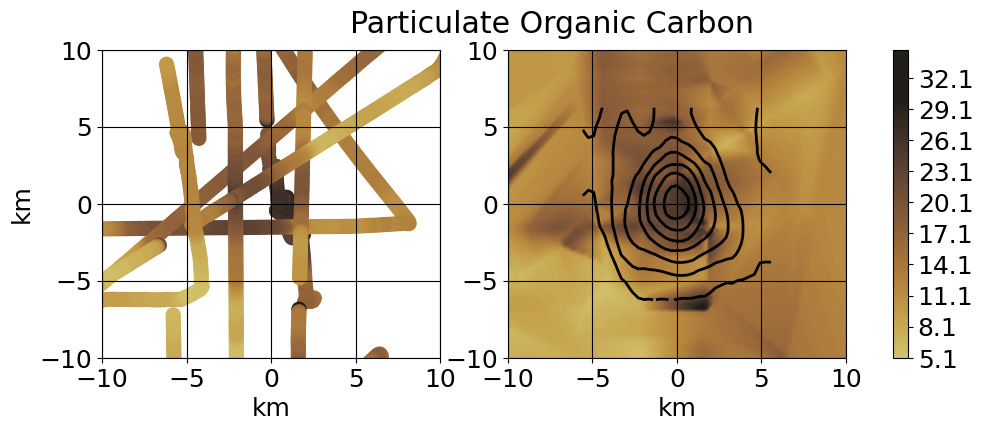

In [741]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
p=ax[0].scatter(dx_km, dy_km, c=dataset_ship.POC,
            s=100, cmap=cm.turbid, vmin=0, vmax=30)
#plt.colorbar(p,ax=ax[0])
ax[0].set_xlim(-10,10); ax[0].set_ylim(-10,10)
ax[0].grid(color='k')

from scipy.interpolate import griddata

# Create grid
xi = np.linspace(dx_km.min(), dx_km.max(), 200)
yi = np.linspace(dy_km.min(), dy_km.max(), 200)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the data onto the grid
zi = griddata((dx_km, dy_km), dataset_ship.POC, (xi, yi), method='linear')
di = np.sqrt(xi.flatten()**2 + yi.flatten()**2)

# Plot with contourf
p=ax[1].contourf(xi, yi, zi, levels=100, cmap=cm.turbid, vmin=0, vmax=30)
#plt.colorbar(p,ax=ax[1],label="Particulate Organic Carbon")
ax[1].set_xlabel("dx (km)")
ax[1].set_ylabel("dy (km)")
ax[1].set_xlim(-10,10); ax[1].set_ylim(-10,10)
ax[1].grid(color='k')
composite_eddy = xr.open_dataset('composite_eddy_centered.nc')
composite_eddy.vor_eddy.plot.contour(levels=np.linspace(-2,2,16),colors='k',linewidths=2)
#(composite_eddy.div_eddy).plot.contour(levels=np.linspace(-2,2,50),colors='k',linewidths=2)

dataset_ship_interpolated = xr.Dataset(
    {
    'POC': xr.DataArray(zi.flatten(),dims='dist_from_core'),
    'dist_from_core': xr.DataArray(di, dims='dist_from_core'),
    },
)
dataset_ship_interpolated = dataset_ship_interpolated.sortby('dist_from_core')

plt.suptitle("Particulate Organic Carbon")
fig.colorbar(p,ax=ax)

for axis in ax: axis.set_xlabel('km'); axis.set_ylabel('')
ax[0].set_ylabel('km')
plt.show()

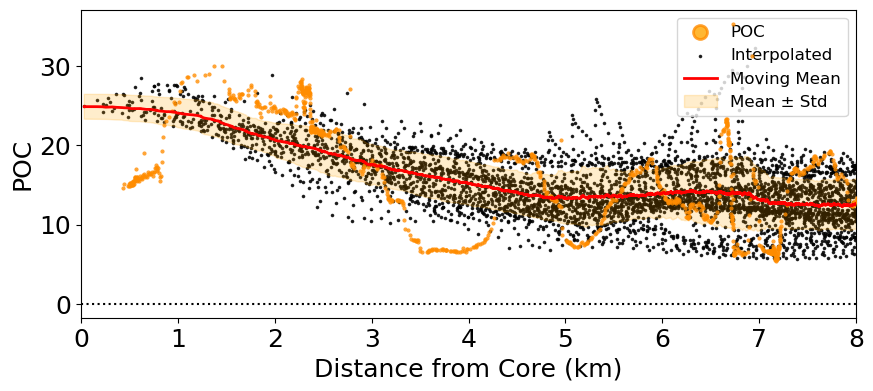

In [749]:
# smooth ship chlorophyll from eddy core

data = dataset_ship_interpolated
# Window size for moving mean and std
window_size = 200#500
moving_std = data.POC.rolling(dist_from_core=window_size, center=True, min_periods=1).std()
moving_mean = data.POC.rolling(dist_from_core=window_size, center=True, min_periods=1).mean()
# Set up the figure

plt.figure(figsize=(10, 4))

# Scatter plot for chlorophyll concentration
plt.scatter(dataset_ship.dist_from_core, dataset_ship.POC, s=1, facecolor='darkorange', edgecolor='darkorange', 
            linewidth=2, marker='o', alpha=0.8, zorder=101)
plt.scatter([],[], s=100, facecolor='orange', edgecolor='darkorange', 
            linewidth=2, marker='o', label='POC', alpha=0.8,)
plt.scatter(di,zi, s=10, facecolor='k', edgecolor='k', 
             marker='.', label='Interpolated', alpha=0.8,)

# Plot the moving mean as an orange line
plt.plot(data.dist_from_core, moving_mean, color='r', label='Moving Mean', linewidth=2,zorder=101)

smooth_mean_chl=moving_mean.rolling(dist_from_core=8, center=True, min_periods=1).mean()
smooth_std_chl=moving_std.rolling(dist_from_core=8, center=True, min_periods=1).mean()

plt.fill_between(data.dist_from_core, 
                 smooth_mean_chl - smooth_std_chl, 
                 smooth_mean_chl + smooth_std_chl, 
                 color='orange', alpha=0.2, label='Mean ± Std')


plt.axhline(0,color='k',linestyle=':')
# Labels, limits, and legend
plt.xlabel('Distance from Core (km)')
plt.ylabel('POC')
#plt.ylim(-2,6)
plt.legend(fontsize=12,loc='upper right')
plt.xlim(0,8)
plt.show()


## Flowrate Control

In [ ]:
ch

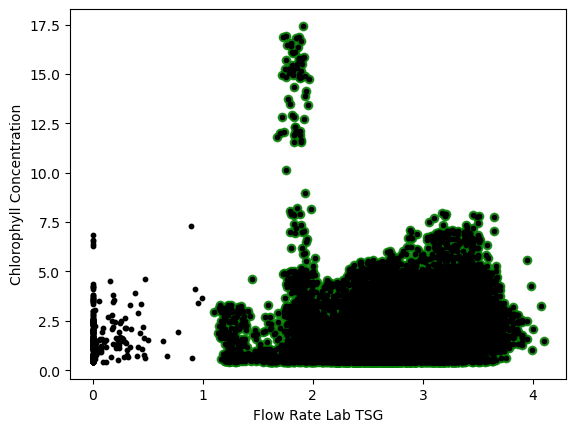

In [56]:
ds=xr.open_dataset('/Users/elise/Desktop/S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
ds = ds.drop_duplicates(dim='time')
chl_ACS = ds.chlorophyll_ACS
flowrate = ds.flow_rate_lab_tsg
# Perform the interpolation
flow_time_bio = ds['flow_rate_lab_tsg'].interp(time=ds['time_bio'], method='linear')

plt.scatter(flow_time_bio,chl_ACS,c='k',s=10,alpha=1,zorder=101)
plt.xlabel('Flow Rate Lab TSG')
plt.ylabel('Chlorophyll Concentration')
idx_keep = np.where(flow_time_bio>1)

plt.scatter(flow_time_bio[idx_keep],chl_ACS[idx_keep],c='g',edgecolor='g',alpha=0.8)

27


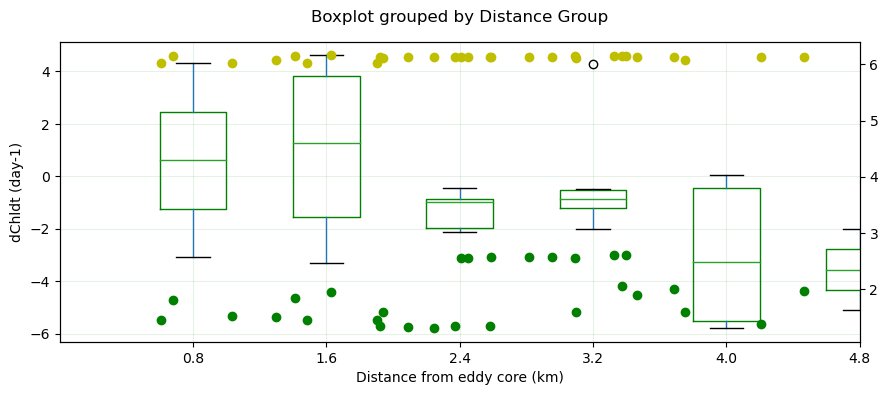

In [246]:
# Boxplot
idx=~np.isnan(dChldt+dist_from_core)

df = pd.DataFrame({
    'Distance from Core': dist_from_core[idx],
    'dChldt': dChldt[idx]
})

print(len(dChldt[iudx]))

bin_width = 0.8
df['Distance Group'] = (np.floor(df['Distance from Core'] / bin_width) * bin_width).round(1)

# Create a box plot grouped by 'Distance Group'
plt.figure(figsize=(10, 4))
df.boxplot(column='dChldt', by='Distance Group', ax=plt.gca(),boxprops=dict(color='green'))
#plt.ylim(-10,10)
plt.grid(color='g',alpha=0.1)
plt.xlabel('Distance from eddy core (km)')
plt.ylabel('dChldt (day-1)')
plt.title('')

#plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/eddy/dChldt_boxplot.png',dpi=800)

# add divergence
X,Y=eddy_composite.shape
#ax2=plt.twinx(plt.gca())
#ax2.plot(x_eddy-np.mean(x_eddy),eddy_composite[:,round(Y/2)])
#ax2.plot(y_eddy-np.mean(x_eddy),eddy_composite[round(Y/2),:])
plt.xlim(0,6)

# add chl
ax2=plt.twinx(plt.gca())
plt.plot(dist_from_core, chl,'og')
#ax2.plot(dist_from_core, temp,'or')
ax2.plot(dist_from_core, o2sat,'oy')

plt.show();